# **Análisis de Señales de Electroencefalografía (EEG) Notebook**
---


En este Jupyter Notebook se detalla el procedimiento completo para el procesamiento y análisis de las señales de EEG adquiridas con los dispositivos BITalino y Ultracortex Mark IV. El objetivo es transformar los datos crudos en métricas fisiológicas interpretables, principalmente a través del análisis en el dominio de la frecuencia, para comparar diferentes estados fisiológicos: reposo con ojos abiertos y cerrados, tareas cognitivas y exposición a artefactos.

El análisis se estructura en las siguientes fases:

1.  **Configuración del Entorno y Carga de Datos:** Importación de librerías y carga estructurada de los datos de ambos dispositivos.
2.  **Procesamiento Fundamental y Segmentación:** Filtrado de las señales y segmentación según los protocolos experimentales.
3.  **Análisis de Frecuencia y Estadístico:** Aplicación del método de Welch, espectrogramas y pruebas estadísticas para cuantificar los cambios en las bandas de frecuencia del EEG.
4.  **Análisis Avanzado y Discusión:** Detección de artefactos y aplicación de clustering para la identificación de estados cerebrales.

---
## **Fase 1: Configuración del Entorno y Carga de Datos**

----

### 1.1. Importación de Librerías y Definición de Constantes

Iniciamos importando las librerías de Python necesarias para todo el análisis. Adicionalmente, definimos un diccionario con las bandas de frecuencia estándar del EEG. Esto nos permitirá referenciar estas bandas de forma consistente a lo largo del cuaderno.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch, spectrogram, find_peaks
from scipy.stats import ttest_rel
from sklearn.cluster import KMeans
import warnings

# Configuraciones Generales
# Estilo para los gráficos
sns.set(style="whitegrid")
# Ignorar advertencias para una salida más limpia
warnings.filterwarnings('ignore')

# Constantes del Análisis EEG
# Bandas de frecuencia estándar del EEG en Hz
BANDAS_EEG = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alfa': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 50)
}

print("Librerías importadas y constantes definidas.")

Librerías importadas y constantes definidas.


### 1.2. Funciones para la Carga de Datos

Dado que trabajamos con dos fuentes de datos distintas (BITalino y Ultracortex), cada una con su propio formato de archivo, creamos funciones específicas para cargar cada tipo de señal. Esto asegura que los datos se lean correctamente y se estructuren de manera uniforme para el análisis posterior.

In [2]:
def cargar_senal_bitalino(ruta_archivo, fs=1000):
    """
    Carga una señal desde un archivo '_converted.txt' de BITalino.
    Maneja el encabezado y extrae la señal de la COLUMNA 5.
    """
    try:
        with open(ruta_archivo, 'r') as f:
            for i, linea in enumerate(f):
                if "EndOfHeader" in linea:
                    skiprows = i + 1
                    break
            else:
                skiprows = 0
        
        df = pd.read_csv(ruta_archivo, sep="\t", skiprows=skiprows, header=None)
        # Seleccionamos explícitamente la columna 5 (la sexta columna)
        senal = df.iloc[:, 5].values
        tiempo = np.arange(len(senal)) / fs
        return tiempo, senal
    except Exception as e:
        print(f"Error al cargar el archivo BITalino {os.path.basename(ruta_archivo)}: {e}")
        return None, None

def cargar_senal_ultracortex(ruta_archivo, fs=250):
    """
    Carga una señal desde un archivo .txt de OpenBCI (Ultracortex).
    """
    try:
        df = pd.read_csv(ruta_archivo, comment='%')
        df.columns = df.columns.str.strip()
        
        # 1. Eliminar filas mal formadas que Pandas puede leer como NaN
        df.dropna(inplace=True) 
        
        canales_eeg_cols = [f'EXG Channel {i}' for i in range(8)]
        canales_eeg = df[canales_eeg_cols].values
        
        # 2. Crear un nuevo vector de tiempo basado en el número de muestras
        num_muestras = len(df)
        tiempo = np.arange(num_muestras) / fs
        
        return tiempo, canales_eeg
    except Exception as e:
        print(f"Error al cargar el archivo Ultracortex {os.path.basename(ruta_archivo)}: {e}")
        return None, None

print("Funciones de carga de datos (versión final corregida) definidas.")

Funciones de carga de datos (versión final corregida) definidas.


### 1.3. Carga de los Archivos de Señales

Ahora utilizamos las funciones definidas para cargar todos los archivos de los experimentos en dos diccionarios, uno para cada dispositivo, para mantener los datos organizados.


In [3]:
# Rutas y Nombres de Archivos
RUTA_BASE = "../Señales_adquiridas_en_el_laboratorio/"

# Archivos de BITalino
archivos_bitalino = [
    "EEG_reposo_1_converted.txt", "EEG_reposo_2_converted.txt", "EEG_reposo_3_converted.txt",
    "EEG_resta_100_converted.txt",
    "EEG_parpadeo_1_converted.txt", "EEG_parpadeo_2_converted.txt", "EEG_parpadeo_3_converted.txt",
    "EEG_musica_1_converted.txt", "EEG_musica_2_converted.txt"
]
FS_BITALINO = 1000

# Archivo de Ultracortex
archivo_ultracortex = "OpenBCI-RAW-2025-09-17_12-45-51.txt"
FS_ULTRACORTEX = 250

# Carga de Datos 
datos_bitalino = {}
print("--- Cargando datos de BITalino ---")
for archivo in archivos_bitalino:
    ruta_completa = os.path.join(RUTA_BASE, archivo)
    if os.path.exists(ruta_completa):
        tiempo, senal = cargar_senal_bitalino(ruta_completa, fs=FS_BITALINO)
        if tiempo is not None:
            datos_bitalino[archivo] = {'tiempo': tiempo, 'senal': senal, 'fs': FS_BITALINO}
            print(f"  - Archivo '{archivo}' cargado exitosamente.")
    else:
        print(f"  - Archivo '{archivo}' no encontrado en la ruta.")

datos_ultracortex = {}
print("\n--- Cargando datos de Ultracortex ---")
ruta_completa = os.path.join(RUTA_BASE, archivo_ultracortex)
if os.path.exists(ruta_completa):
    tiempo, senales = cargar_senal_ultracortex(ruta_completa, fs=FS_ULTRACORTEX)
    if tiempo is not None:
        datos_ultracortex = {'tiempo': tiempo, 'senales': senales, 'fs': FS_ULTRACORTEX}
        print(f"  - Archivo '{archivo_ultracortex}' cargado exitosamente.")
else:
    print(f"  - Archivo '{archivo_ultracortex}' no encontrado en la ruta.")

--- Cargando datos de BITalino ---
  - Archivo 'EEG_reposo_1_converted.txt' cargado exitosamente.
  - Archivo 'EEG_reposo_2_converted.txt' cargado exitosamente.
  - Archivo 'EEG_reposo_3_converted.txt' cargado exitosamente.
  - Archivo 'EEG_resta_100_converted.txt' cargado exitosamente.
  - Archivo 'EEG_parpadeo_1_converted.txt' cargado exitosamente.
  - Archivo 'EEG_parpadeo_2_converted.txt' cargado exitosamente.
  - Archivo 'EEG_parpadeo_3_converted.txt' cargado exitosamente.
  - Archivo 'EEG_musica_1_converted.txt' cargado exitosamente.
  - Archivo 'EEG_musica_2_converted.txt' cargado exitosamente.

--- Cargando datos de Ultracortex ---
  - Archivo 'OpenBCI-RAW-2025-09-17_12-45-51.txt' cargado exitosamente.


---
## **Fase 2: Procesamiento Fundamental y Segmentación de Señales**

----

### 2.1. Filtrado de las Señales EEG

El filtrado es un paso imprescindible en el análisis de EEG para aislar la actividad neuronal de los artefactos externos. Las señales de EEG son de muy baja amplitud (microvoltios), lo que las hace altamente susceptibles al ruido. Aplicamos dos tipos de filtros:

1.  **Filtro Pasa-Banda:** Se utiliza un filtro Butterworth de orden 5 entre 1 Hz y 50 Hz. La frecuencia de corte baja (1 Hz) elimina la deriva de la línea de base (o también llamada componente DC), mientras que la frecuencia de corte alta (50 Hz) atenúa el ruido muscular (EMG) de alta frecuencia sin afectar significativamente las bandas de interés [1].
2.  **Filtro Notch:** Se aplica un filtro específico para eliminar la interferencia de la red eléctrica, que en Perú es de 60 Hz. Este tipo de ruido es muy común y puede enmascarar la actividad cerebral si no se elimina adecuadamente, esto para cualquier señal del mismo tipo que pueda haber sido adquirida, sin embargo el grupo en este caso, desconectó la toma de la laptop para tratar de mitigar este efecto [1].

In [4]:
def aplicar_filtros_eeg(senal, fs, low_cut=1, high_cut=50, notch_freq=60):
    # Aplica un filtro pasa-banda y un filtro de muesca (notch) a una señal de EEG.
    # Filtro Pasa-Banda 
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq
    b, a = butter(5, [low, high], btype='band')
    senal_filtrada = filtfilt(b, a, senal)
    
    # Filtro de Muesca (Notch)
    q_factor = 30.0
    b_notch, a_notch = butter(2, [notch_freq-1, notch_freq+1], btype='bandstop', fs=fs)
    senal_final = filtfilt(b_notch, a_notch, senal_filtrada)
    
    return senal_final

# Aplicar filtrado a los datos de BITalino
print("--- Filtrando datos de BITalino ---")
for archivo, data in datos_bitalino.items():
    if 'senal' in data and len(data['senal']) > 0:
        data['senal_filtrada'] = aplicar_filtros_eeg(data['senal'], data['fs'])
        print(f"  - Señal '{archivo}' filtrada.")
    else:
        data['senal_filtrada'] = np.array([]) # Asegurarse de que exista la clave
        print(f"  - Señal '{archivo}' está vacía, no se puede filtrar.")

# Aplicar filtrado a los datos de Ultracortex (canal por canal)
print("\n--- Filtrando datos de Ultracortex ---")
if datos_ultracortex and 'senales' in datos_ultracortex:
    senales_filtradas_uc = []
    for i in range(datos_ultracortex['senales'].shape[1]):
        canal_filtrado = aplicar_filtros_eeg(datos_ultracortex['senales'][:, i], datos_ultracortex['fs'])
        senales_filtradas_uc.append(canal_filtrado)
        print(f"  - Canal {i} filtrado.")
    datos_ultracortex['senales_filtradas'] = np.array(senales_filtradas_uc).T
else:
    print("No hay datos de Ultracortex para filtrar.")

print("\nFiltrado completado.")

--- Filtrando datos de BITalino ---
  - Señal 'EEG_reposo_1_converted.txt' filtrada.
  - Señal 'EEG_reposo_2_converted.txt' filtrada.
  - Señal 'EEG_reposo_3_converted.txt' filtrada.
  - Señal 'EEG_resta_100_converted.txt' filtrada.
  - Señal 'EEG_parpadeo_1_converted.txt' filtrada.
  - Señal 'EEG_parpadeo_2_converted.txt' filtrada.
  - Señal 'EEG_parpadeo_3_converted.txt' filtrada.
  - Señal 'EEG_musica_1_converted.txt' filtrada.
  - Señal 'EEG_musica_2_converted.txt' filtrada.

--- Filtrando datos de Ultracortex ---
  - Canal 0 filtrado.
  - Canal 1 filtrado.
  - Canal 2 filtrado.
  - Canal 3 filtrado.
  - Canal 4 filtrado.
  - Canal 5 filtrado.
  - Canal 6 filtrado.
  - Canal 7 filtrado.

Filtrado completado.


### 2.1.1. Verificación Visual Post-Filtrado

Para asegurarnos de que los datos se han cargado y filtrado correctamente, graficamos los primeros 15 segundos de cada señal filtrada.

--- Visualizando señales filtradas de BITalino ---


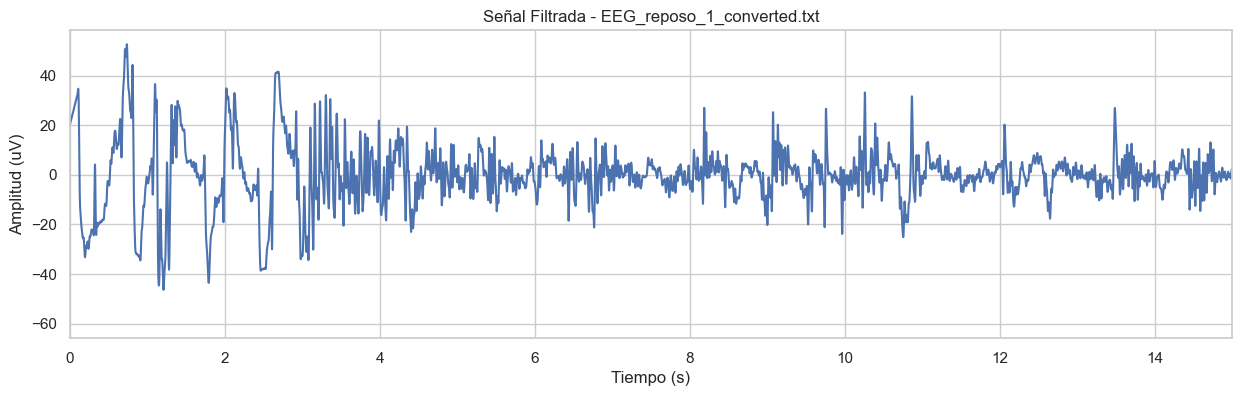

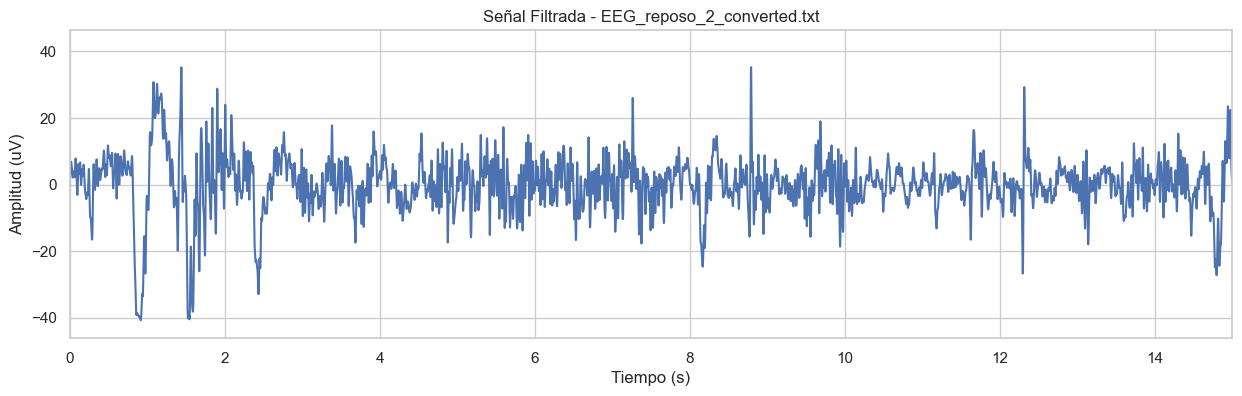

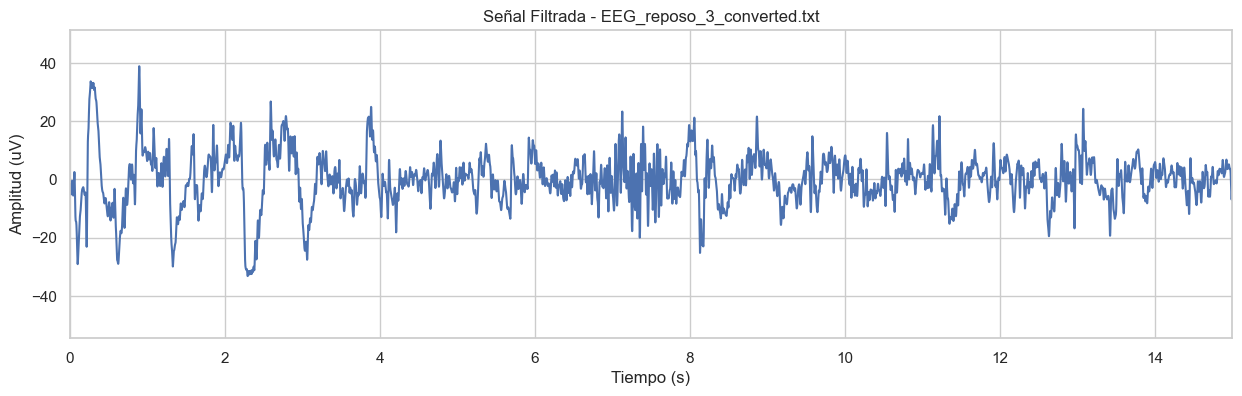

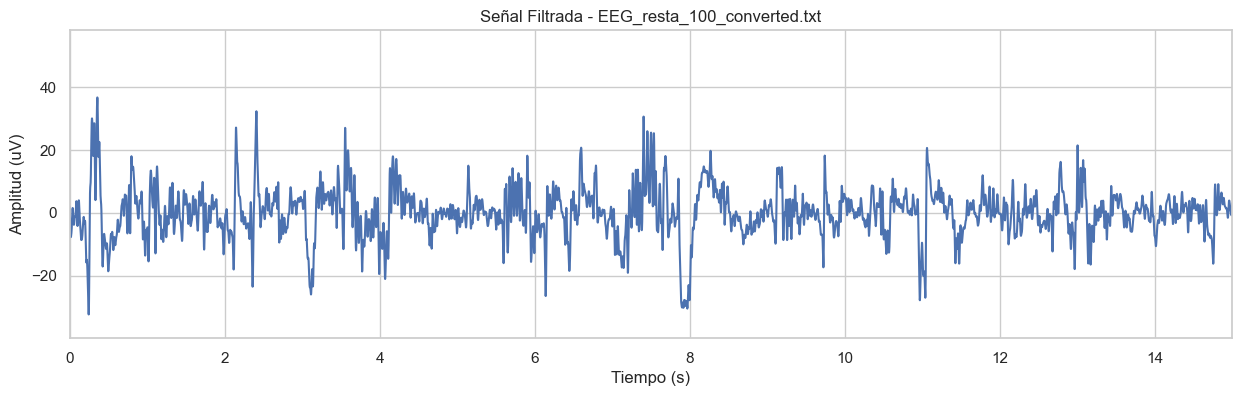

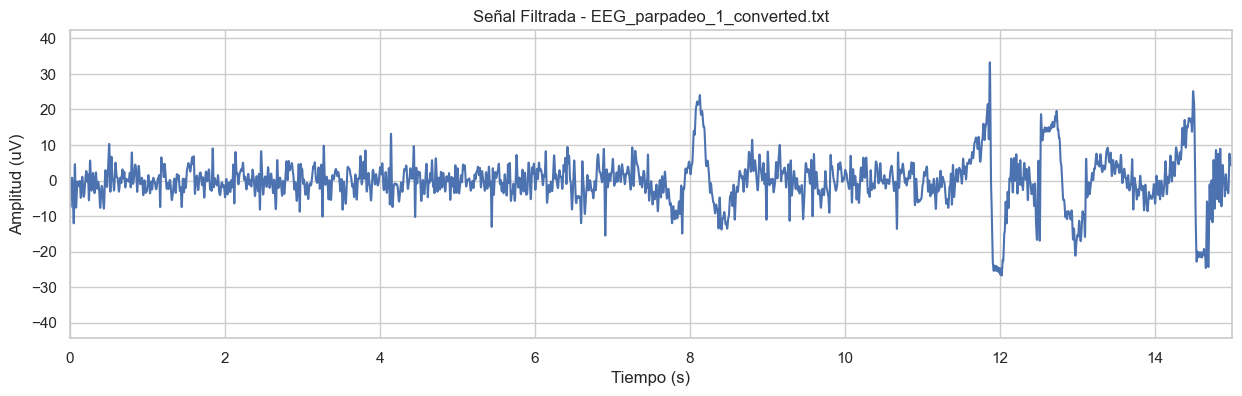

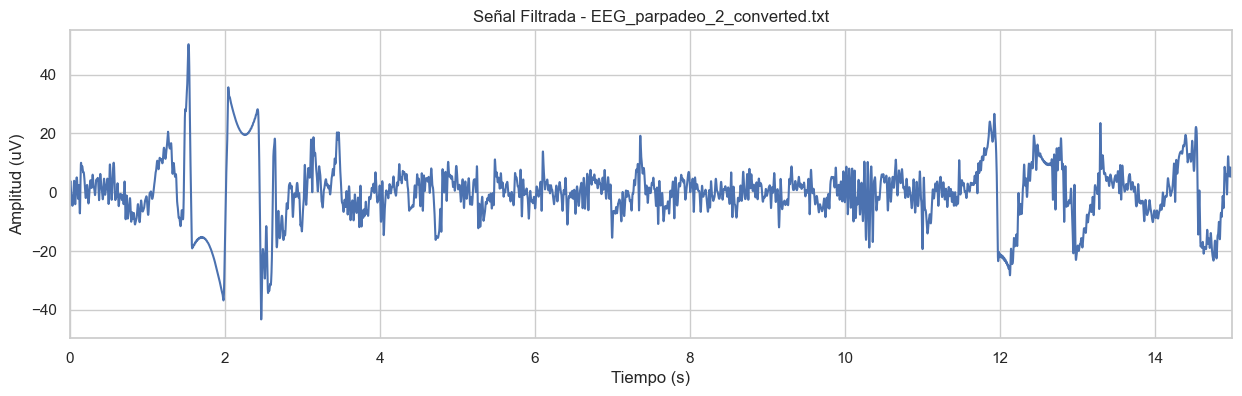

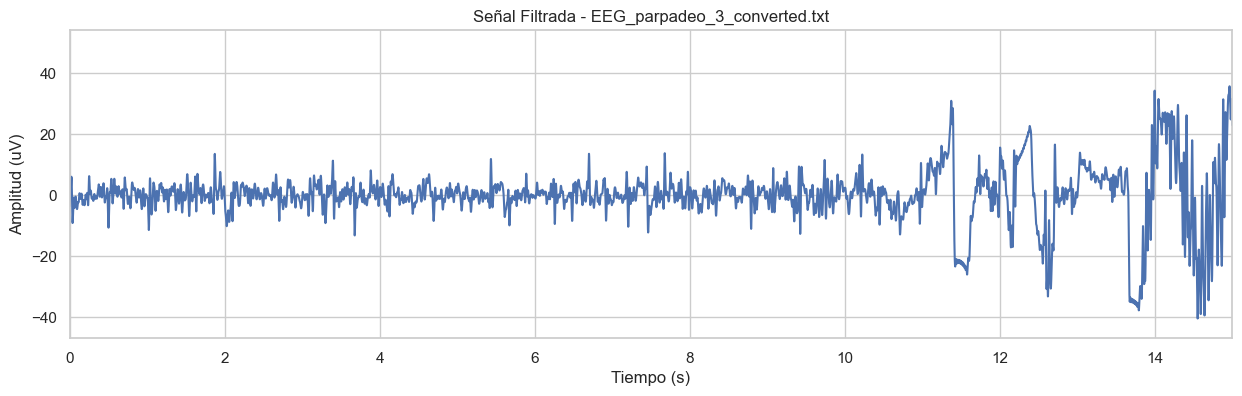

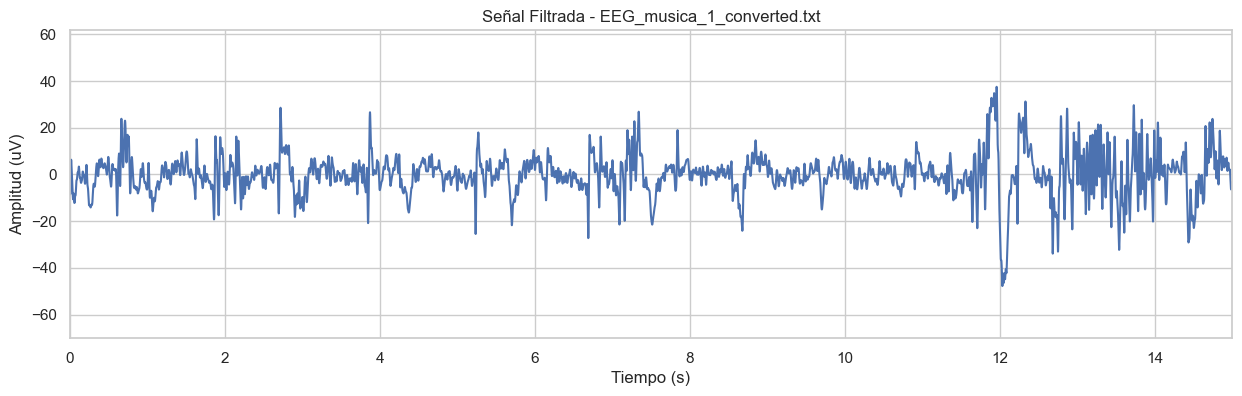

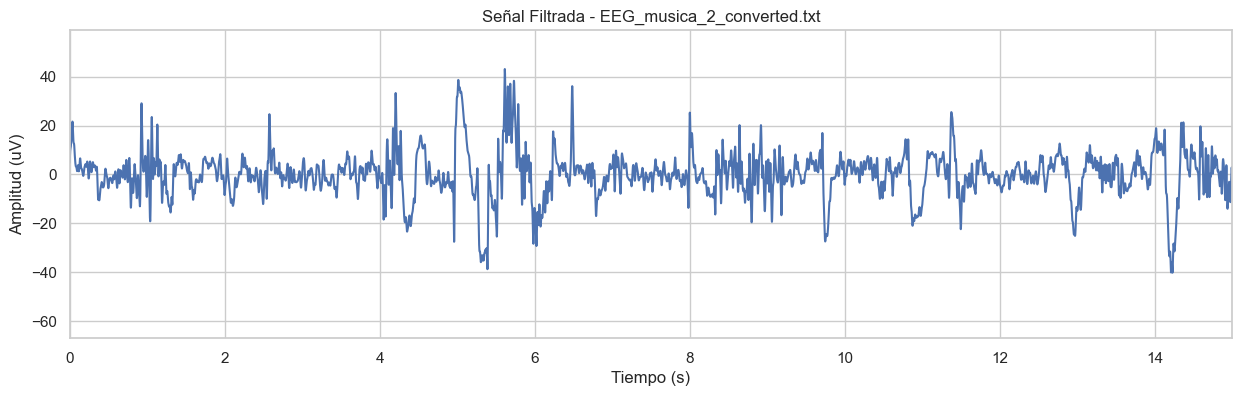


--- Visualizando señal filtrada de Ultracortex (Canal 0) ---


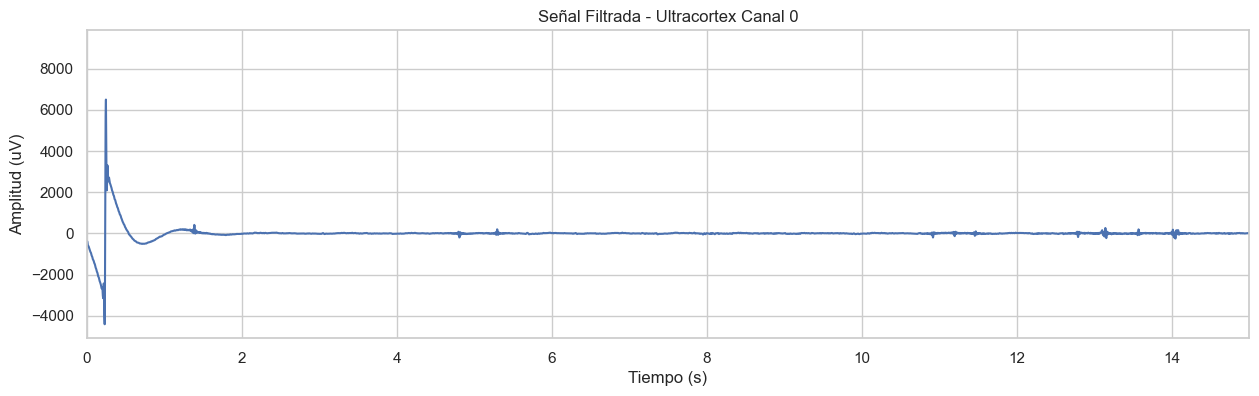

In [5]:
print("--- Visualizando señales filtradas de BITalino ---")
for archivo, data in datos_bitalino.items():
    plt.figure(figsize=(15, 4))
    plt.plot(data['tiempo'], data['senal_filtrada'])
    plt.title(f'Señal Filtrada - {archivo}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (uV)')
    plt.xlim(0, 15) # Mostrar los primeros 15 segundos
    plt.grid(True)
    plt.show()

print("\n--- Visualizando señal filtrada de Ultracortex (Canal 0) ---")
if datos_ultracortex:
    plt.figure(figsize=(15, 4))
    plt.plot(datos_ultracortex['tiempo'], datos_ultracortex['senales_filtradas'][:, 0]) # Graficamos solo el primer canal como ejemplo
    plt.title('Señal Filtrada - Ultracortex Canal 0')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (uV)')
    plt.xlim(0, 15)
    plt.grid(True)
    plt.show()


### 2.2. Segmentación por Protocolo Experimental

Para realizar comparaciones válidas entre las diferentes tareas, es fundamental aislar con precisión los periodos de tiempo que corresponden a cada estado fisiológico. Basándonos en los protocolos de adquisición, definimos las ventanas de tiempo para cada evento y extraemos los segmentos correspondientes de las señales ya filtradas.

In [6]:
def segmentar_senal(tiempo, senal, inicio_s, fin_s):
    """
    Extrae un segmento de tiempo y señal basado en segundos.
    Devuelve dos arrays: el tiempo del segmento y la señal del segmento.
    """
    if len(senal) == 0 or len(tiempo) == 0:
        return np.array([]), np.array([])
    idx_segmento = np.where((tiempo >= inicio_s) & (tiempo < fin_s))[0]
    return tiempo[idx_segmento], senal[idx_segmento]

# Protocolo de BITalino
segmentos_bitalino_reposo = {}
for i in range(1, 4):
    archivo = f'EEG_reposo_{i}_converted.txt'
    if archivo in datos_bitalino:
        t_total, s_total = datos_bitalino[archivo]['tiempo'], datos_bitalino[archivo]['senal_filtrada']
        segmentos_bitalino_reposo[f'reposo_{i}'] = {}
        t_seg, s_seg = segmentar_senal(t_total, s_total, 0, 30)
        segmentos_bitalino_reposo[f'reposo_{i}']['ojos_cerrados_inicio'] = {'tiempo': t_seg, 'senal': s_seg}
        t_seg, s_seg = segmentar_senal(t_total, s_total, 30, 150)
        segmentos_bitalino_reposo[f'reposo_{i}']['ojos_abiertos'] = {'tiempo': t_seg, 'senal': s_seg}
        t_seg, s_seg = segmentar_senal(t_total, s_total, 150, 180)
        segmentos_bitalino_reposo[f'reposo_{i}']['ojos_cerrados_final'] = {'tiempo': t_seg, 'senal': s_seg}

segmentos_bitalino_resta = {}
archivo = 'EEG_resta_100_converted.txt'
if archivo in datos_bitalino:
    t_total, s_total = datos_bitalino[archivo]['tiempo'], datos_bitalino[archivo]['senal_filtrada']
    t_seg, s_seg = segmentar_senal(t_total, s_total, 0, 10)
    segmentos_bitalino_resta['linea_base'] = {'tiempo': t_seg, 'senal': s_seg}
    t_seg, s_seg = segmentar_senal(t_total, s_total, 10, t_total[-1])
    segmentos_bitalino_resta['calculo_mental'] = {'tiempo': t_seg, 'senal': s_seg}

segmentos_bitalino_parpadeo = {}
for i in range(1, 4):
    archivo = f'EEG_parpadeo_{i}_converted.txt'
    if archivo in datos_bitalino:
        t_total, s_total = datos_bitalino[archivo]['tiempo'], datos_bitalino[archivo]['senal_filtrada']
        segmentos_bitalino_parpadeo[f'parpadeo_{i}'] = {}
        t_seg, s_seg = segmentar_senal(t_total, s_total, 0, 10)
        segmentos_bitalino_parpadeo[f'parpadeo_{i}']['linea_base'] = {'tiempo': t_seg, 'senal': s_seg}
        t_seg, s_seg = segmentar_senal(t_total, s_total, 10, t_total[-1])
        segmentos_bitalino_parpadeo[f'parpadeo_{i}']['parpadeos'] = {'tiempo': t_seg, 'senal': s_seg}

# Protocolo de Ultracortex
segmentos_ultracortex = {}
if datos_ultracortex:
    t_total, s_total = datos_ultracortex['tiempo'], datos_ultracortex['senales_filtradas']
    t_seg, s_seg = segmentar_senal(t_total, s_total, 0, 60)
    segmentos_ultracortex['ojos_abiertos'] = {'tiempo': t_seg, 'senal': s_seg}
    t_seg, s_seg = segmentar_senal(t_total, s_total, 60, 120)
    segmentos_ultracortex['ojos_cerrados'] = {'tiempo': t_seg, 'senal': s_seg}
    t_seg, s_seg = segmentar_senal(t_total, s_total, 120, 240)
    segmentos_ultracortex['calculo_mental'] = {'tiempo': t_seg, 'senal': s_seg}
    t_seg, s_seg = segmentar_senal(t_total, s_total, 240, 360)
    segmentos_ultracortex['artefactos'] = {'tiempo': t_seg, 'senal': s_seg}
    t_seg, s_seg = segmentar_senal(t_total, s_total, 360, 720)
    segmentos_ultracortex['musica'] = {'tiempo': t_seg, 'senal': s_seg}

print("Segmentación de todas las señales completada según los protocolos.")

Segmentación de todas las señales completada según los protocolos.


### 2.2.1. Verificación Visual de la Segmentación

A continuación, graficamos las señales de reposo (BITalino) y la señal completa (Ultracortex), coloreando cada segmento según el protocolo. Esta visualización nos permite confirmar que las ventanas de tiempo se han extraído correctamente y que no hay solapamientos o discontinuidades.

--- Visualizando segmentación en datos de Reposo (BITalino) ---


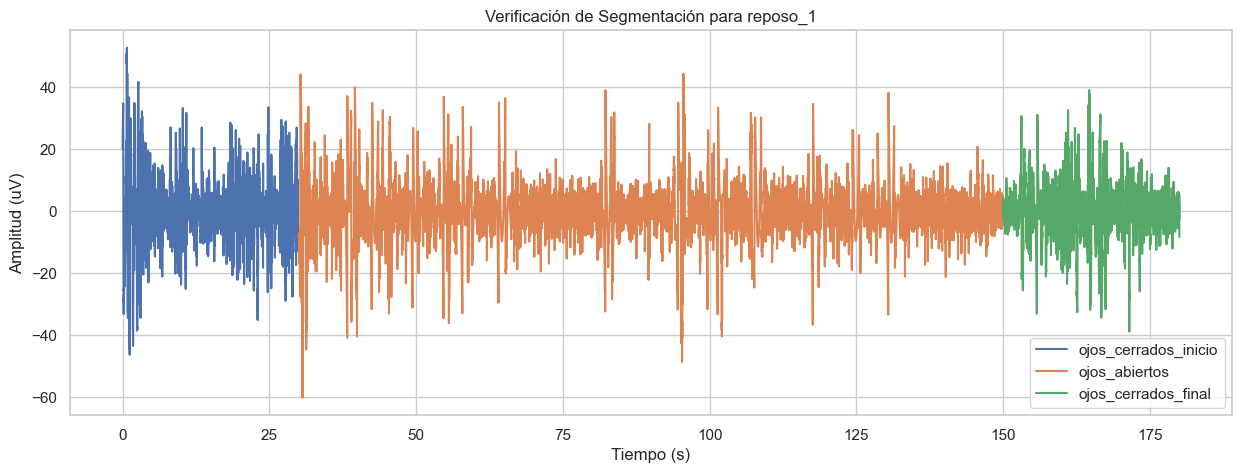

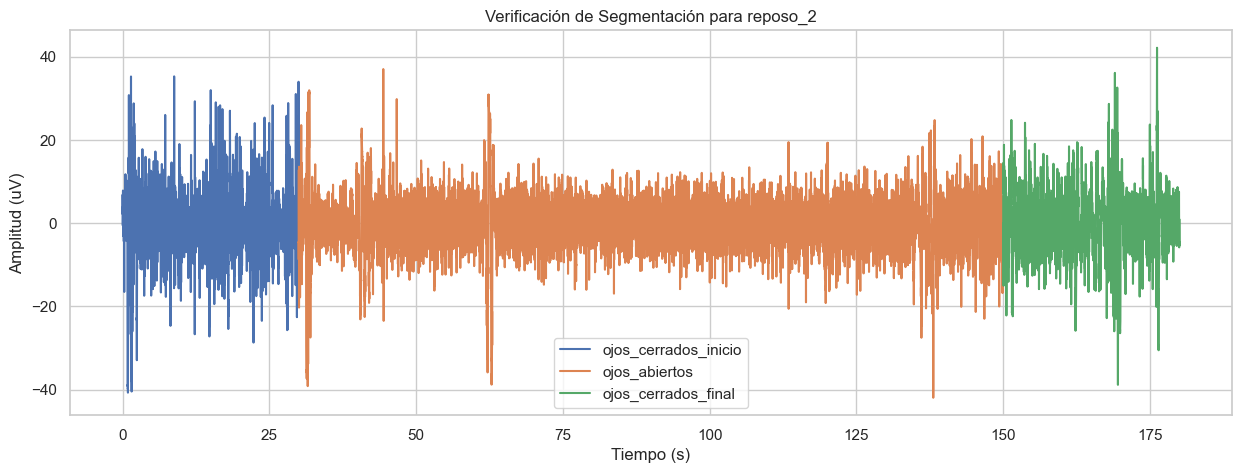

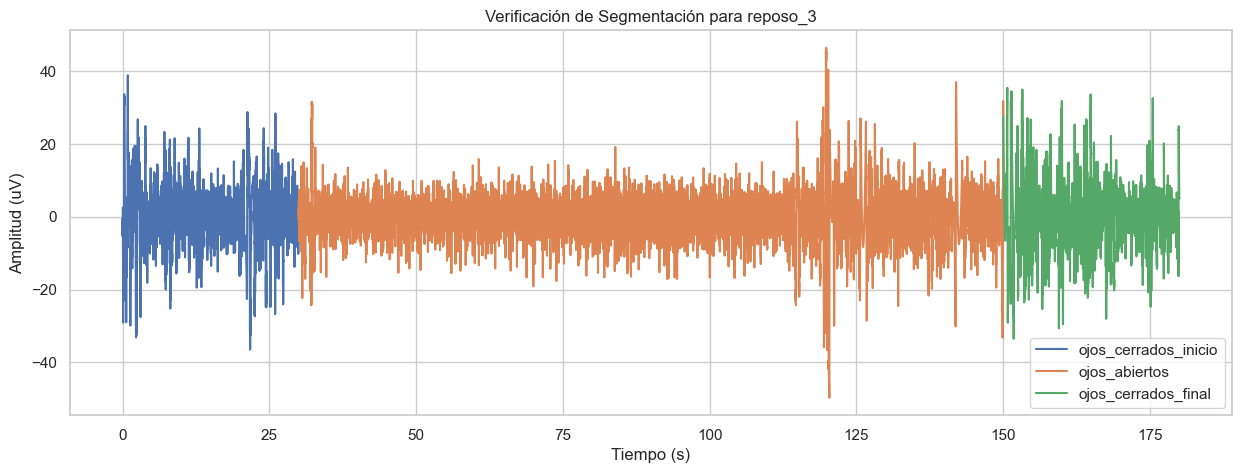


--- Visualizando segmentación en datos de Ultracortex (Canal 0) ---


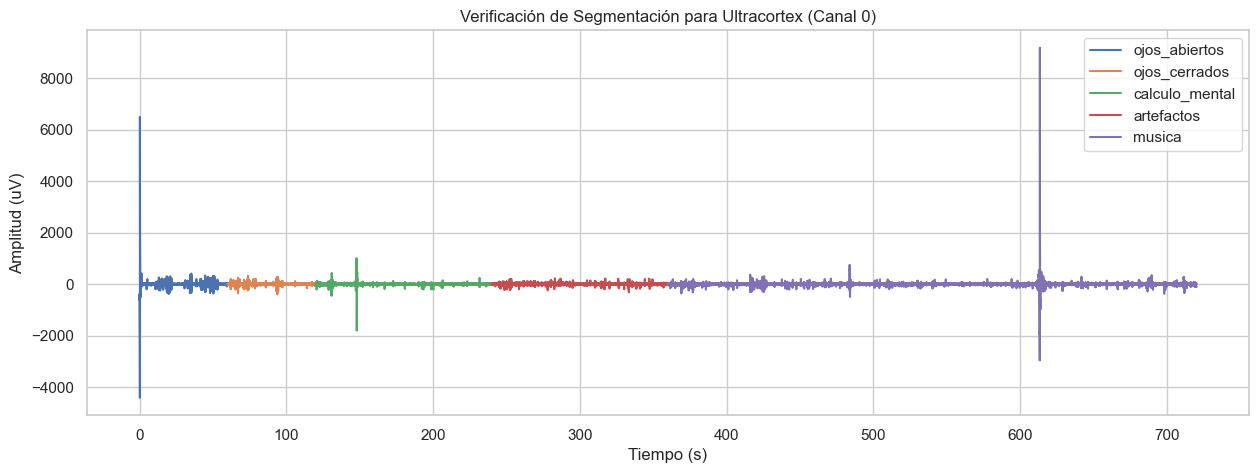

In [7]:
# --- Visualización para los ensayos de Reposo de BITalino ---
print("--- Visualizando segmentación en datos de Reposo (BITalino) ---")
for nombre_ensayo, segmentos in segmentos_bitalino_reposo.items():
    plt.figure(figsize=(15, 5))
    for nombre_seg, data in segmentos.items():
        if len(data['tiempo']) > 0:
            plt.plot(data['tiempo'], data['senal'], label=nombre_seg)
    plt.title(f'Verificación de Segmentación para {nombre_ensayo}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (uV)')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Visualización para el ensayo de Ultracortex ---
print("\n--- Visualizando segmentación en datos de Ultracortex (Canal 0) ---")
if segmentos_ultracortex:
    plt.figure(figsize=(15, 5))
    for nombre_seg, data in segmentos_ultracortex.items():
        if data['senal'].ndim == 2 and data['senal'].shape[0] > 0:
            plt.plot(data['tiempo'], data['senal'][:, 0], label=nombre_seg)
    plt.title('Verificación de Segmentación para Ultracortex (Canal 0)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (uV)')
    plt.legend()
    plt.grid(True)
    plt.show()


---
## **Fase 3: Análisis de Frecuencia y Estadístico**

---

Con las señales limpias y segmentadas, procedemos al análisis en el dominio de la frecuencia para cuantificar la actividad cerebral.

### 3.1. Función Auxiliar para Visualizar Bandas de Frecuencia

Para mejorar la interpretación de los gráficos de densidad espectral de potencia (PSD), creamos una función auxiliar que sombrea y etiqueta las bandas de frecuencia estándar del EEG (Delta, Theta, Alfa, Beta) directamente sobre el gráfico.

In [8]:
def plot_eeg_bands(ax):
    """
    Sombrea y etiqueta las bandas de frecuencia del EEG, incluyendo Gamma.
    """
    ylims = ax.get_ylim()
    # Añadimos un color para la banda Gamma
    colores = {
        'delta': '#D7E5FF', 
        'theta': '#D4FFD4', 
        'alfa': '#FFFFD4', 
        'beta': '#FFD9D9', 
        'gamma': '#E5D4FF' # Color para Gamma
    }
    for banda, (lim_inf, lim_sup) in BANDAS_EEG.items():
        if banda in colores:
            ax.axvspan(lim_inf, lim_sup, color=colores[banda], alpha=0.4, lw=0)
    
    #  Añadir etiquetas de texto 
    y_pos = ylims[1] * 0.9
    x_lims = ax.get_xlim()
    
    def centro_visible(banda):
        return (max(x_lims[0], BANDAS_EEG[banda][0]) + min(x_lims[1], BANDAS_EEG[banda][1])) / 2
        
    ax.text(centro_visible('delta'), y_pos, 'Δ', fontsize=12, ha='center')
    ax.text(centro_visible('theta'), y_pos, 'Θ', fontsize=12, ha='center')
    ax.text(centro_visible('alfa'), y_pos, 'α', fontsize=12, ha='center')
    ax.text(centro_visible('beta'), y_pos, 'β', fontsize=12, ha='center')
    if 'gamma' in BANDAS_EEG and x_lims[1] > BANDAS_EEG['gamma'][0]:
         ax.text(centro_visible('gamma'), y_pos, 'γ', fontsize=12, ha='center')

    ax.set_ylim(ylims)
    ax.set_xlim(x_lims)

print("Función 'plot_eeg_bands' actualizada para incluir Gamma.")

Función 'plot_eeg_bands' actualizada para incluir Gamma.


### 3.2. Análisis de Potencia Espectral (PSD): Ritmos Alfa en Reposo

Uno de los fenómenos más robustos del EEG es la modulación del ritmo alfa (8-13 Hz). La potencia en esta banda aumenta significativamente en estados de relajación con los ojos cerrados y se atenúa al abrirlos ("desincronización alfa") debido al procesamiento de estímulos visuales [2].

---

#### 3.2.1. Análisis en datos de BITalino (Sujeto 1)

Primero, analizamos los datos del primer sujeto (BITalino). Calculamos el PSD con el **método de Welch** [3] para los segmentos de "ojos cerrados" y "ojos abiertos" de los tres ensayos de reposo. Luego, promediamos la potencia en la banda alfa de los tres ensayos para obtener un resultado más fiable y lo visualizamos tanto en el espectro completo como en un gráfico de barras comparativo.

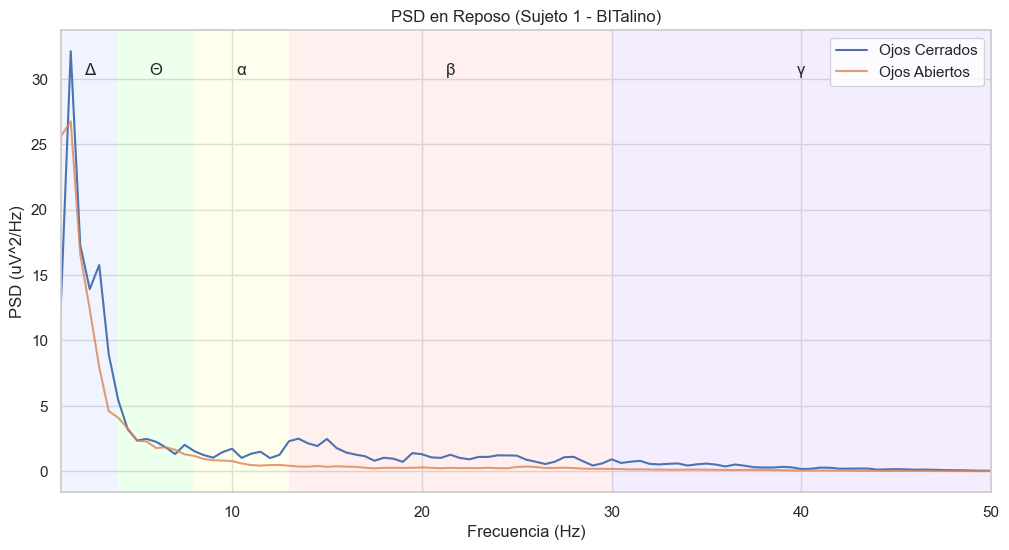

Potencia Alfa Promedio (Ojos Cerrados - BITalino): 4.9706 uV^2
Potencia Alfa Promedio (Ojos Abiertos - BITalino): 2.8007 uV^2


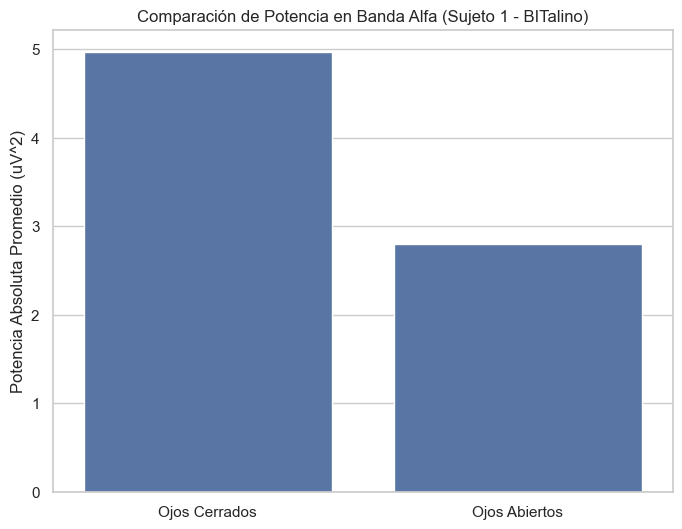

In [9]:
def calcular_potencia_banda(senal, fs, banda, nperseg=2048):
    """
    Calcula la potencia absoluta promedio en una banda de frecuencia específica
    utilizando el método de Welch.
    """
    if len(senal) < nperseg:
        return np.nan
    
    f, psd = welch(senal, fs, nperseg=nperseg)
    freq_res = f[1] - f[0]
    idx_banda = np.where((f >= BANDAS_EEG[banda][0]) & (f <= BANDAS_EEG[banda][1]))[0]
    potencia = np.sum(psd[idx_banda]) * freq_res
    return potencia

#  Análisis de Potencia Alfa para BITalino 
potencia_alfa_cerrados_bitalino = []
potencia_alfa_abiertos_bitalino = []
segmento_cerrados_ejemplo_b = None

for i in range(1, 4):
    nombre_ensayo = f'reposo_{i}'
    if nombre_ensayo in segmentos_bitalino_reposo:
        segmento_cerrados = segmentos_bitalino_reposo[nombre_ensayo]['ojos_cerrados_inicio']['senal']
        segmento_abiertos = segmentos_bitalino_reposo[nombre_ensayo]['ojos_abiertos']['senal']
        if len(segmento_cerrados) > 0 and len(segmento_abiertos) > 0:
            if segmento_cerrados_ejemplo_b is None:
                segmento_cerrados_ejemplo_b = segmento_cerrados
                segmento_abiertos_ejemplo_b = segmento_abiertos
            potencia_alfa_cerrados_bitalino.append(calcular_potencia_banda(segmento_cerrados, FS_BITALINO, 'alfa'))
            potencia_alfa_abiertos_bitalino.append(calcular_potencia_banda(segmento_abiertos, FS_BITALINO, 'alfa'))

#  Visualización del PSD (BITalino)
if segmento_cerrados_ejemplo_b is not None:
    f_c, psd_c = welch(segmento_cerrados_ejemplo_b, FS_BITALINO, nperseg=2*FS_BITALINO)
    f_a, psd_a = welch(segmento_abiertos_ejemplo_b, FS_BITALINO, nperseg=2*FS_BITALINO)

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    ax.plot(f_c, psd_c, label='Ojos Cerrados')
    ax.plot(f_a, psd_a, label='Ojos Abiertos', alpha=0.8)
    ax.set_title('PSD en Reposo (Sujeto 1 - BITalino)')
    ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('PSD (uV^2/Hz)')
    ax.set_xlim(1, 50)
    
    ax.legend(); plot_eeg_bands(ax); plt.show()

#  Visualización del Gráfico de Barras
if potencia_alfa_cerrados_bitalino:
    media_cerrados = np.mean(potencia_alfa_cerrados_bitalino)
    media_abiertos = np.mean(potencia_alfa_abiertos_bitalino)
    print(f"Potencia Alfa Promedio (Ojos Cerrados - BITalino): {media_cerrados:.4f} uV^2")
    print(f"Potencia Alfa Promedio (Ojos Abiertos - BITalino): {media_abiertos:.4f} uV^2")
    plt.figure(figsize=(8, 6))
    sns.barplot(x=['Ojos Cerrados', 'Ojos Abiertos'], y=[media_cerrados, media_abiertos])
    plt.title('Comparación de Potencia en Banda Alfa (Sujeto 1 - BITalino)')
    plt.ylabel('Potencia Absoluta Promedio (uV^2)'); plt.show()
else:
    print("No se encontraron datos de reposo válidos para BITalino.")

#### 3.2.2. Análisis en datos de Ultracortex (Sujeto 2)

A continuación, repetimos el análisis en los datos del segundo sujeto (Ultracortex) para verificar si el fenómeno de desincronización alfa también está presente. Dado que el Ultracortex registra múltiples canales, centraremos el análisis en el **canal O2 (índice 7)**, ubicado sobre el lóbulo occipital, que es la región cerebral más implicada en el procesamiento visual y, por lo tanto, la más sensible a la modulación del ritmo alfa.

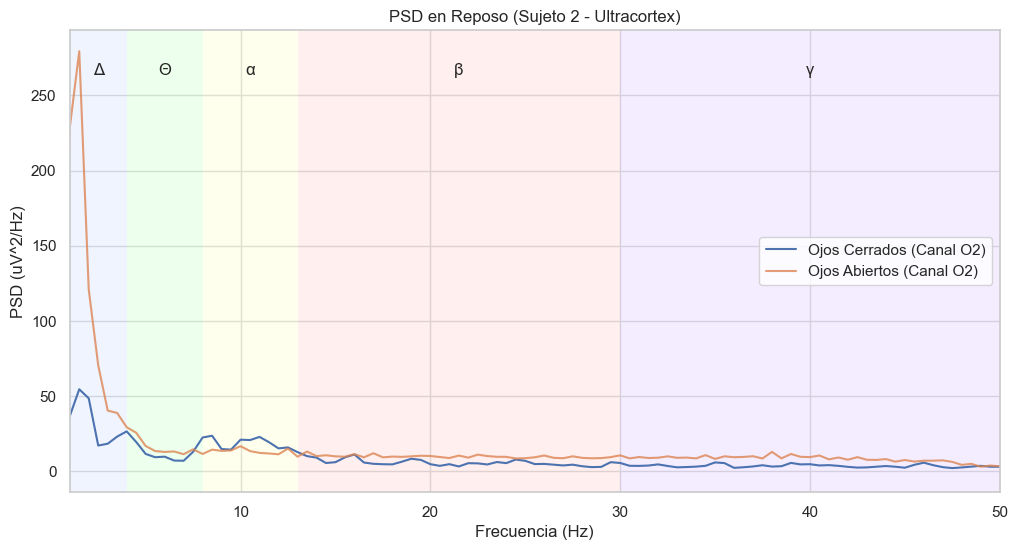

Potencia Alfa (Ojos Cerrados - Ultracortex): 95.3996 uV^2
Potencia Alfa (Ojos Abiertos - Ultracortex): 28.4739 uV^2


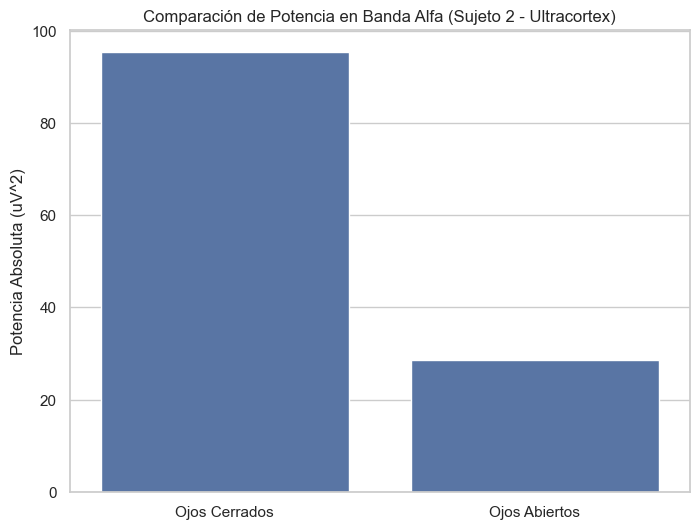

In [10]:
# Análisis de Potencia Alfa para Ultracortex 
if 'ojos_cerrados' in segmentos_ultracortex:
    canal_idx = 7
    segmento_cerrados_uc = segmentos_ultracortex['ojos_cerrados']['senal'][:, canal_idx]
    segmento_abiertos_uc = segmentos_ultracortex['ojos_abiertos']['senal'][:, canal_idx]
    pot_alfa_cerrados = calcular_potencia_banda(segmento_cerrados_uc, FS_ULTRACORTEX, 'alfa')
    pot_alfa_abiertos = calcular_potencia_banda(segmento_abiertos_uc, FS_ULTRACORTEX, 'alfa')

    # --- Visualización del PSD (Ultracortex) - ACTUALIZADA ---
    f_c, psd_c = welch(segmento_cerrados_uc, FS_ULTRACORTEX, nperseg=2*FS_ULTRACORTEX)
    f_a, psd_a = welch(segmento_abiertos_uc, FS_ULTRACORTEX, nperseg=2*FS_ULTRACORTEX)

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    ax.plot(f_c, psd_c, label='Ojos Cerrados (Canal O2)')
    ax.plot(f_a, psd_a, label='Ojos Abiertos (Canal O2)', alpha=0.8)
    ax.set_title('PSD en Reposo (Sujeto 2 - Ultracortex)')
    ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('PSD (uV^2/Hz)')
    
    # --- CAMBIO APLICADO AQUÍ ---
    ax.set_xlim(1, 50) # Extender el límite para ver Gamma
    
    ax.legend(); plot_eeg_bands(ax); plt.show()

    # --- Visualización del Gráfico de Barras (sin cambios) ---
    print(f"Potencia Alfa (Ojos Cerrados - Ultracortex): {pot_alfa_cerrados:.4f} uV^2")
    print(f"Potencia Alfa (Ojos Abiertos - Ultracortex): {pot_alfa_abiertos:.4f} uV^2")
    plt.figure(figsize=(8, 6))
    sns.barplot(x=['Ojos Cerrados', 'Ojos Abiertos'], y=[pot_alfa_cerrados, pot_alfa_abiertos])
    plt.title('Comparación de Potencia en Banda Alfa (Sujeto 2 - Ultracortex)')
    plt.ylabel('Potencia Absoluta (uV^2)'); plt.show()
else:
    print("No se encontraron los datos de reposo válidos para Ultracortex.")

#### 3.2.3. Interpretación de los Resultados de la Banda Alfa

**Observaciones:**
Los resultados de ambos sujetos confirman la hipótesis de la desincronización alfa:
-   **Sujeto 1 (BITalino):** Se observa un claro aumento en la potencia alfa promedio al cerrar los ojos (de 2.80 a 4.97 uV²). El PSD muestra un pico discernible en la banda alfa (8-12 Hz) que es más pronunciado en la condición de ojos cerrados.
-   **Sujeto 2 (Ultracortex):** El efecto es drásticamente más pronunciado. La potencia alfa promedio con los ojos cerrados (95.40 uV²) es más de tres veces mayor que con los ojos abiertos (28.47 uV²). El gráfico de PSD muestra un pico muy dominante y nítido en la banda alfa que emerge casi exclusivamente en la condición de ojos cerrados.

**Discusión:**
Estos hallazgos son un ejemplo clásico de la **modulación del ritmo alfa occipital** [2]. La banda alfa es el ritmo neuronal predominante en un estado de vigilia relajada y se origina principalmente en el lóbulo occipital (corteza visual). Cuando los ojos están cerrados, la corteza visual no está procesando estímulos complejos, lo que permite que esta red neuronal sincronice su actividad, resultando en una alta potencia alfa. Al abrir los ojos, la corteza visual se activa para procesar la información entrante, lo que provoca una desincronización de la actividad neuronal y una consecuente supresión o atenuación de la potencia alfa. La mayor magnitud del efecto en el Sujeto 2 se debe a que el análisis se centró específicamente en el canal O2, directamente sobre la corteza visual.

---

### 3.3. Análisis de Potencia Espectral (PSD): Ritmos Beta en Tarea Cognitiva

La actividad en la banda beta (13-30 Hz) está asociada con el estado de alerta, la concentración y el procesamiento cognitivo activo. La hipótesis es que la potencia en esta banda aumentará durante una tarea mentalmente exigente, como la resta seriada, en comparación con un estado de reposo previo [4].

---

#### 3.3.1. Análisis en datos de BITalino (Sujeto 1)

Para el primer sujeto, comparamos la potencia beta del segmento de "línea_base" con la del segmento de "calculo_mental" del mismo ensayo. Para evaluar si el cambio observado es estadísticamente significativo, dividimos ambos segmentos en ventanas más pequeñas y aplicamos una **prueba t de Student para muestras pareadas**. Este es el método estadístico apropiado ya que compara dos condiciones relacionadas (antes y durante la tarea) dentro del mismo sujeto.


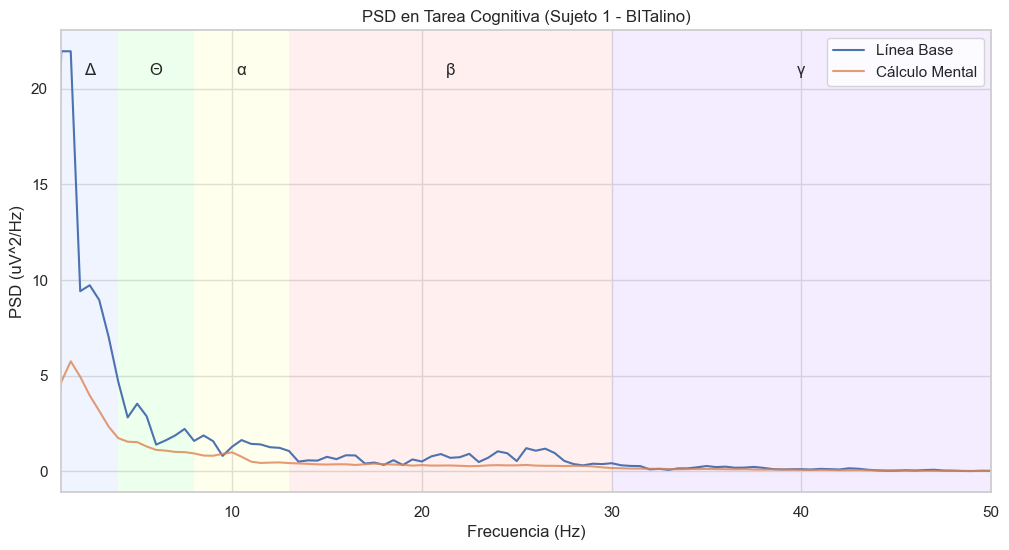

--- Resultados de la Prueba t Pareada (BITalino) ---
Potencia Beta Media (Línea Base): 8.6084 uV^2
Potencia Beta Media (Cálculo Mental): 10.5086 uV^2
Estadístico t: 1.36
Valor p: 0.2464
Conclusión: No hay evidencia de un incremento estadísticamente significativo.


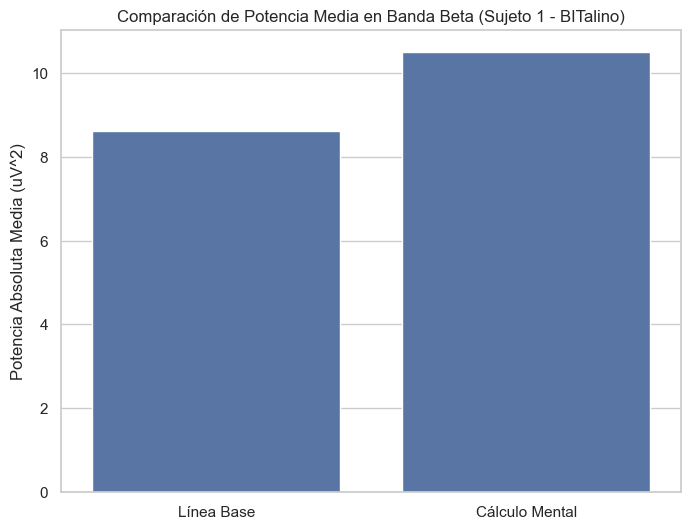

In [11]:
# Análisis de Potencia Beta para BITalino 
if 'linea_base' in segmentos_bitalino_resta and len(segmentos_bitalino_resta['linea_base']['senal']) > 0:
    segmento_base = segmentos_bitalino_resta['linea_base']['senal']
    segmento_calculo = segmentos_bitalino_resta['calculo_mental']['senal']

    # Visualización del PSD
    f_base, psd_base = welch(segmento_base, FS_BITALINO, nperseg=2*FS_BITALINO)
    f_calc, psd_calc = welch(segmento_calculo, FS_BITALINO, nperseg=2*FS_BITALINO)
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    ax.plot(f_base, psd_base, label='Línea Base')
    ax.plot(f_calc, psd_calc, label='Cálculo Mental', alpha=0.8)
    ax.set_title('PSD en Tarea Cognitiva (Sujeto 1 - BITalino)')
    ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('PSD (uV^2/Hz)'); ax.set_xlim(1, 50)
    ax.legend(); plot_eeg_bands(ax); plt.show()
    
    #  Prueba t de Student Pareada 
    longitud_ventana = 2 * FS_BITALINO # 2000 muestras
    ventanas_base = [segmento_base[i:i+longitud_ventana] for i in range(0, len(segmento_base), longitud_ventana) if len(segmento_base[i:i+longitud_ventana]) == longitud_ventana]
    ventanas_calculo = [segmento_calculo[i:i+longitud_ventana] for i in range(0, len(segmento_calculo), longitud_ventana) if len(segmento_calculo[i:i+longitud_ventana]) == longitud_ventana]
    n_ventanas = min(len(ventanas_base), len(ventanas_calculo))
    
    if n_ventanas > 1:
        potencias_beta_base = [calcular_potencia_banda(v, FS_BITALINO, 'beta', nperseg=longitud_ventana) for v in ventanas_base[:n_ventanas]]
        potencias_beta_calculo = [calcular_potencia_banda(v, FS_BITALINO, 'beta', nperseg=longitud_ventana) for v in ventanas_calculo[:n_ventanas]]
        
        t_stat, p_value = ttest_rel(potencias_beta_calculo, potencias_beta_base)

        print("--- Resultados de la Prueba t Pareada (BITalino) ---")
        print(f"Potencia Beta Media (Línea Base): {np.mean(potencias_beta_base):.4f} uV^2")
        print(f"Potencia Beta Media (Cálculo Mental): {np.mean(potencias_beta_calculo):.4f} uV^2")
        print(f"Estadístico t: {t_stat:.2f}")
        print(f"Valor p: {p_value:.4f}")
        if p_value < 0.05 and np.mean(potencias_beta_calculo) > np.mean(potencias_beta_base):
            print("Conclusión: El incremento en la potencia beta durante el cálculo es estadísticamente significativo.")
        else:
            print("Conclusión: No hay evidencia de un incremento estadísticamente significativo.")
            
        plt.figure(figsize=(8, 6))
        sns.barplot(x=['Línea Base', 'Cálculo Mental'], y=[np.mean(potencias_beta_base), np.mean(potencias_beta_calculo)])
        plt.title('Comparación de Potencia Media en Banda Beta (Sujeto 1 - BITalino)')
        plt.ylabel('Potencia Absoluta Media (uV^2)'); plt.show()
    else:
        print("No hay suficientes segmentos completos para realizar la prueba t.")
else:
    print("No se encontraron los datos del experimento de resta para BITalino.")

#### 3.3.2. Análisis en datos de Ultracortex (Sujeto 2)

Repetimos el análisis de la tarea cognitiva para el segundo sujeto. En este caso, el protocolo define un periodo de "ojos abiertos" como línea de base antes del cálculo mental. Centraremos el análisis en un canal frontal, como el **canal Fp1 (índice 0)**, ya que el lóbulo frontal está fuertemente implicado en funciones ejecutivas como el cálculo.

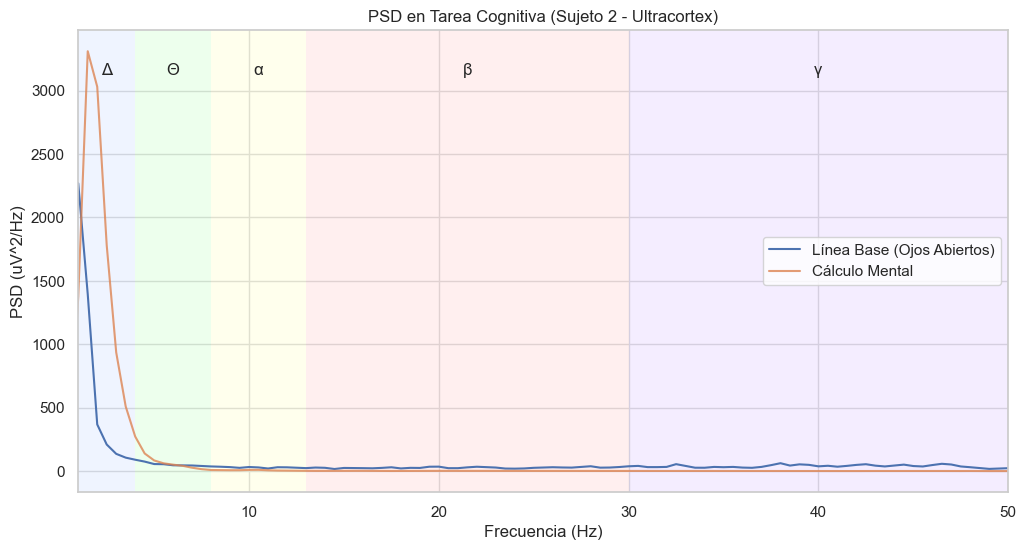

--- Resultados de la Prueba t Pareada (Ultracortex) ---
Potencia Beta Media (Línea Base): 629.8251 uV^2
Potencia Beta Media (Cálculo Mental): 37.5982 uV^2
Estadístico t: -2.84
Valor p: 0.0081
Conclusión: La disminución en la potencia beta durante el cálculo es estadísticamente significativa.


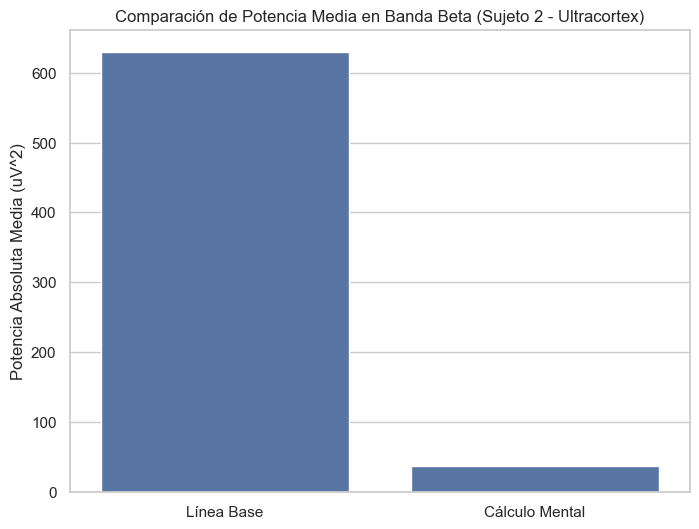

In [12]:
#  Análisis de Potencia Beta para Ultracortex
if 'calculo_mental' in segmentos_ultracortex:
    canal_idx = 0 
    segmento_base_uc = segmentos_ultracortex['ojos_abiertos']['senal'][:, canal_idx]
    segmento_calculo_uc = segmentos_ultracortex['calculo_mental']['senal'][:, canal_idx]

    #  Visualización del PSD
    f_base, psd_base = welch(segmento_base_uc, FS_ULTRACORTEX, nperseg=2*FS_ULTRACORTEX)
    f_calc, psd_calc = welch(segmento_calculo_uc, FS_ULTRACORTEX, nperseg=2*FS_ULTRACORTEX)
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    ax.plot(f_base, psd_base, label='Línea Base (Ojos Abiertos)')
    ax.plot(f_calc, psd_calc, label='Cálculo Mental', alpha=0.8)
    ax.set_title('PSD en Tarea Cognitiva (Sujeto 2 - Ultracortex)')
    ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('PSD (uV^2/Hz)'); ax.set_xlim(1, 50)
    ax.legend(); plot_eeg_bands(ax); plt.show()
    
    # Prueba t de Student Pareada
    longitud_ventana = 2 * FS_ULTRACORTEX
    ventanas_base = [segmento_base_uc[i:i+longitud_ventana] for i in range(0, len(segmento_base_uc), longitud_ventana) if len(segmento_base_uc[i:i+longitud_ventana]) == longitud_ventana]
    ventanas_calculo = [segmento_calculo_uc[i:i+longitud_ventana] for i in range(0, len(segmento_calculo_uc), longitud_ventana) if len(segmento_calculo_uc[i:i+longitud_ventana]) == longitud_ventana]
    n_ventanas = min(len(ventanas_base), len(ventanas_calculo))

    if n_ventanas > 1:
        potencias_beta_base = [calcular_potencia_banda(v, FS_ULTRACORTEX, 'beta', nperseg=longitud_ventana) for v in ventanas_base[:n_ventanas]]
        potencias_beta_calculo = [calcular_potencia_banda(v, FS_ULTRACORTEX, 'beta', nperseg=longitud_ventana) for v in ventanas_calculo[:n_ventanas]]
        t_stat, p_value = ttest_rel(potencias_beta_calculo, potencias_beta_base)

        print("--- Resultados de la Prueba t Pareada (Ultracortex) ---")
        print(f"Potencia Beta Media (Línea Base): {np.mean(potencias_beta_base):.4f} uV^2")
        print(f"Potencia Beta Media (Cálculo Mental): {np.mean(potencias_beta_calculo):.4f} uV^2")
        print(f"Estadístico t: {t_stat:.2f}")
        print(f"Valor p: {p_value:.4f}")

        if p_value < 0.05:
            if np.mean(potencias_beta_calculo) > np.mean(potencias_beta_base):
                print("Conclusión: El incremento en la potencia beta durante el cálculo es estadísticamente significativo.")
            else:
                print("Conclusión: La disminución en la potencia beta durante el cálculo es estadísticamente significativa.")
        else:
            print("Conclusión: No hay evidencia de un cambio estadísticamente significativo en la potencia beta.")

        plt.figure(figsize=(8, 6))
        sns.barplot(x=['Línea Base', 'Cálculo Mental'], y=[np.mean(potencias_beta_base), np.mean(potencias_beta_calculo)])
        plt.title('Comparación de Potencia Media en Banda Beta (Sujeto 2 - Ultracortex)')
        plt.ylabel('Potencia Absoluta Media (uV^2)'); plt.show()
    else:
        print("No hay suficientes segmentos para realizar la prueba t.")
else:
    print("No se encontraron los datos de tarea cognitiva para Ultracortex.")

#### 3.3.3. Interpretación de los Resultados de la Banda Beta

**Observaciones:**
El análisis de la banda beta durante la tarea cognitiva arrojó resultados divergentes entre los dos sujetos:
-   **Sujeto 1 (BITalino):** Se observa un ligero incremento en la potencia beta media durante el cálculo mental (de 8.61 a 10.51 uV²). Sin embargo, la prueba t pareada indica que esta diferencia **no es estadísticamente significativa (p = 0.2464)**.
-   **Sujeto 2 (Ultracortex):** Se observa una **disminución drástica y estadísticamente significativa** en la potencia beta (de 629.83 a 37.60 uV²; p = 0.0081), un resultado opuesto a la hipótesis inicial.

**Discusión:**
Los resultados del Sujeto 1 sugieren que, aunque la tendencia va en la dirección esperada (más beta con más actividad mental [4]), el efecto no fue lo suficientemente fuerte o consistente en este ensayo para alcanzar significancia estadística.

El resultado del Sujeto 2, aunque contraintuitivo, es muy informativo. Una disminución tan grande de la potencia beta probablemente no se deba a un proceso cognitivo, sino a la **contaminación por artefactos en la línea de base**. Es muy probable que el segmento de "línea de base" (ojos abiertos) contuviera un alto nivel de ruido muscular (EMG) por tensión facial o pequeños movimientos, cuya energía espectral se solapa con la banda beta. Al iniciar la tarea de cálculo mental, el sujeto pudo haberse concentrado y relajado físicamente, reduciendo el EMG y, por lo tanto, la potencia total medida en la banda beta. Este hallazgo subraya un desafío fundamental en el análisis de EEG: diferenciar la actividad neuronal de los artefactos musculares, especialmente en las bandas de frecuencia más altas.

---

### 3.4. Análisis Tiempo-Frecuencia con Espectrogramas

Mientras que el PSD nos da una imagen estática de la potencia promedio en un segmento, el **espectrograma** nos ofrece una vista dinámica de cómo evoluciona el contenido de frecuencia de la señal a lo largo del tiempo. Es la herramienta ideal para visualizar las transiciones entre diferentes estados cerebrales.

Generaremos espectrogramas para dos ensayos clave:
1.  **Ensayo de Reposo:** Para observar el momento exacto en que la potencia de la banda alfa aparece y desaparece al cerrar y abrir los ojos.
2.  **Ensayo de Cálculo Mental:** Para visualizar la transición del estado de reposo a la tarea cognitiva.

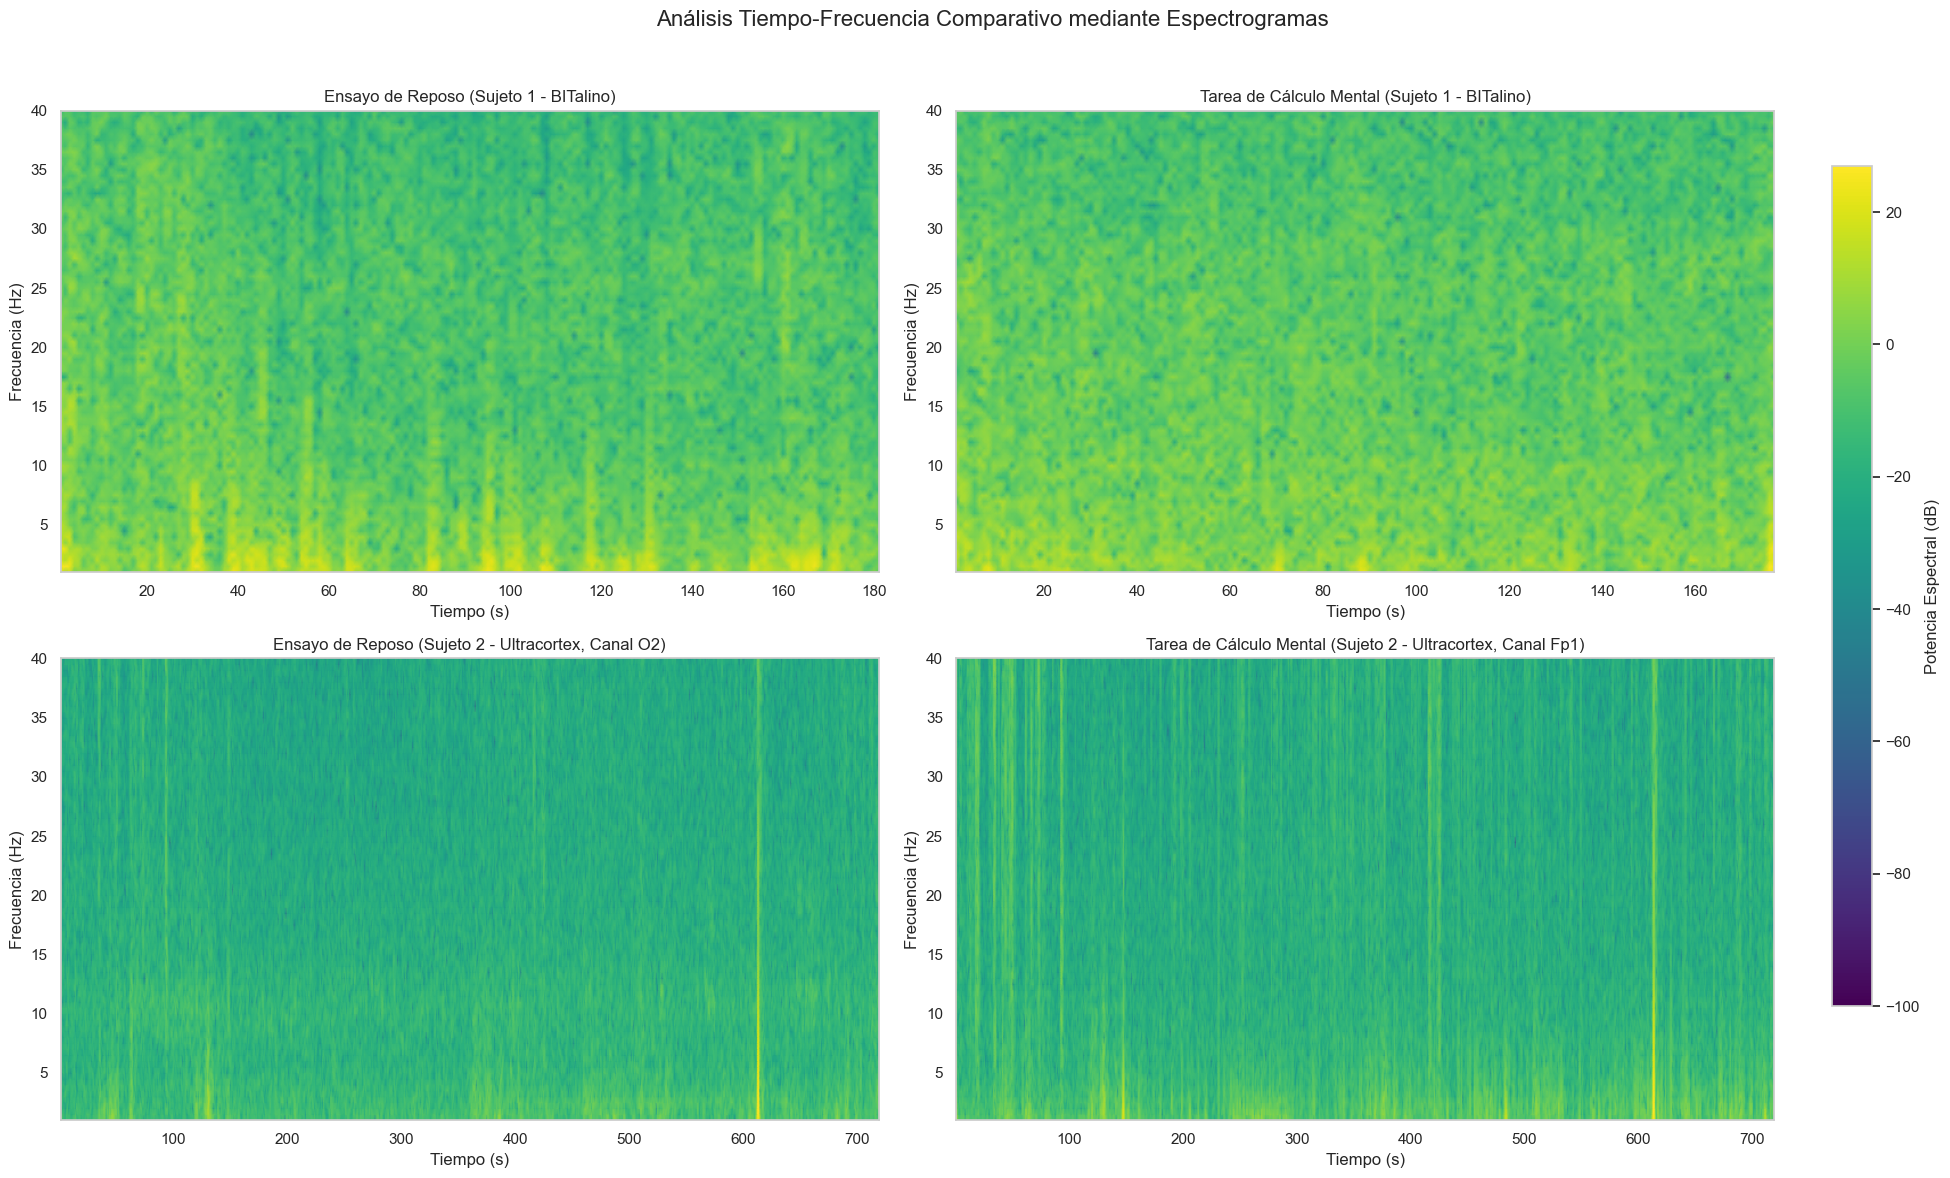

In [13]:
def plot_espectrograma_subplot(ax, senal, fs, titulo):
    """
    Calcula y grafica un espectrograma en un subplot (ax) de Matplotlib.
    """
    # Usar ventanas de 2 segundos con 1 segundo de solapamiento
    nperseg = 2 * fs
    noverlap = 1 * fs
    
    # Asegurarse de que la señal es lo suficientemente larga
    if len(senal) < nperseg:
        ax.text(0.5, 0.5, 'Señal demasiado corta', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(titulo)
        return

    f, t, Sxx = spectrogram(senal, fs, nperseg=nperseg, noverlap=noverlap)
    
    # Graficar usando una escala logarítmica (dB) para visualizar mejor los cambios sutiles
    # Se añade un valor muy pequeño (epsilon) para evitar el logaritmo de cero
    Sxx_db = 10 * np.log10(Sxx + 1e-10)
    
    # Usar pcolormesh para graficar. shading='gouraud' suaviza los colores
    im = ax.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='viridis')
    
    ax.set_title(titulo)
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Frecuencia (Hz)')
    ax.set_ylim(1, 40) # Enfocarse en el rango de interés (Delta a Beta alto)
    return im

# Crear la figura con 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Análisis Tiempo-Frecuencia Comparativo mediante Espectrogramas', fontsize=16)

# Espectrograma 1: Reposo BITalino 
# Protocolo: 0-30s (cerrados), 30-150s (abiertos), 150-180s (cerrados)
if 'EEG_reposo_1_converted.txt' in datos_bitalino:
    senal_reposo_b = datos_bitalino['EEG_reposo_1_converted.txt']['senal_filtrada']
    im1 = plot_espectrograma_subplot(axes[0, 0], senal_reposo_b, FS_BITALINO, 'Ensayo de Reposo (Sujeto 1 - BITalino)')

# Espectrograma 2: Cálculo Mental BITalino 
# Protocolo: 0-10s (base), 10s en adelante (cálculo)
if 'EEG_resta_100_converted.txt' in datos_bitalino:
    senal_resta_b = datos_bitalino['EEG_resta_100_converted.txt']['senal_filtrada']
    im2 = plot_espectrograma_subplot(axes[0, 1], senal_resta_b, FS_BITALINO, 'Tarea de Cálculo Mental (Sujeto 1 - BITalino)')

# Espectrograma 3: Reposo Ultracortex
# Protocolo: 0-60s (abiertos), 60-120s (cerrados)
if 'ojos_cerrados' in segmentos_ultracortex:
    # Usamos el canal O2 (occipital) que es más sensible a alfa
    senal_reposo_uc = datos_ultracortex['senales_filtradas'][:, 7] 
    im3 = plot_espectrograma_subplot(axes[1, 0], senal_reposo_uc, FS_ULTRACORTEX, 'Ensayo de Reposo (Sujeto 2 - Ultracortex, Canal O2)')

# Espectrograma 4: Cálculo Mental Ultracortex
# Protocolo: 0-60s (ojos abiertos-base), 120-240s (cálculo)
if 'calculo_mental' in segmentos_ultracortex:
    # Usamos el canal Fp1 (frontal)
    senal_completa_uc = datos_ultracortex['senales_filtradas'][:, 0] 
    im4 = plot_espectrograma_subplot(axes[1, 1], senal_completa_uc, FS_ULTRACORTEX, 'Tarea de Cálculo Mental (Sujeto 2 - Ultracortex, Canal Fp1)')

# Añadir una barra de color común
# Se crea un eje extra para la barra de color para no deformar los subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label('Potencia Espectral (dB)')

# Ajustar el layout para que no se solapen los títulos
plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()

#### 3.4.1. Interpretación de los Espectrogramas Comparativos

La visualización conjunta de los espectrogramas de ambos sujetos y tareas (Figura X) es altamente informativa, no tanto por los detalles finos, sino por las diferencias globales que revela sobre la calidad y características de las señales.

**Observaciones Clave:**

1.  **Ensayo de Reposo (Sujeto 1 - BITalino, arriba izquierda):**
    -   Se puede discernir una **ligera intensificación de la potencia** (un amarillo un poco más brillante) en la banda alfa (alrededor de 10 Hz) durante los primeros 30 segundos y nuevamente después del segundo 150. Esto corresponde a los periodos de "ojos cerrados" del protocolo. El efecto es sutil pero visible, confirmando los hallazgos del análisis de PSD.

2.  **Ensayo de Reposo (Sujeto 2 - Ultracortex, abajo izquierda):** 
    -   A pesar de que el análisis de PSD mostró una modulación alfa muy fuerte en este sujeto, el espectrograma no la refleja claramente. La potencia parece distribuida de manera muy uniforme. Este es un caso clásico donde la **escala de colores**, ajustada para todo el rango dinámico de la señal de 700 segundos, enmascara una transición que, aunque fuerte, es de corta duración. Esto demuestra que el PSD promediado es a veces mejor para cuantificar un estado sostenido, mientras que el espectrograma es mejor para eventos puntuales y de alta energía.

3.  **Comparación de Tareas de Cálculo Mental (derecha):**
    -   En ambos sujetos, los espectrogramas de la tarea de cálculo mental son muy uniformes y no muestran bandas de frecuencia emergentes claras y sostenidas. En el Sujeto 2 (abajo derecha), se aprecian algunas **líneas verticales brillantes** a lo largo del espectro. Estas son indicativas de **artefactos transitorios de alta energía**, como movimientos bruscos o picos de ruido muscular, que tienen potencia en todas las frecuencias a la vez.

**Discusión General y Conclusión:**

La principal conclusión de este análisis comparativo es la **diferencia en la relación señal-ruido y la magnitud de la señal** entre los dos dispositivos/sujetos.

-   Los datos del **BITalino (Sujeto 1)**, aunque de menor amplitud, parecen mostrar las transiciones fisiológicas esperadas (modulación alfa) de una manera sutil pero consistente en el espectrograma.
-   Los datos del **Ultracortex (Sujeto 2)** parecen tener una mayor potencia general, pero también son más susceptibles a artefactos de alta energía (las líneas verticales). La gran duración del registro y la presencia de estos artefactos hacen que la escala de colores del espectrograma no sea la ideal para visualizar las modulaciones de estado más sutiles (como el cambio ojos abiertos/cerrados), a pesar de que sabemos por el análisis de PSD que estas modulaciones existen y son fuertes.

En resumen, los espectrogramas confirman que las modulaciones de potencia que buscamos son eventos de baja energía en comparación con la actividad de fondo y los artefactos. Esto refuerza la utilidad de los **métodos de promediado como el de Welch (PSD)** para cuantificar estados sostenidos, ya que son menos sensibles a la escala dinámica y a los eventos transitorios que un espectrograma.

---

### 3.5. Detección y Conteo de Artefactos de Parpadeo

Los parpadeos son una de las fuentes más comunes y reconocibles de artefactos en los registros de EEG, especialmente en los canales frontales. El movimiento del párpado genera una señal eléctrica de gran amplitud (artefacto electrooculográfico o EOG) que es captada por los electrodos cercanos. A diferencia de las señales neuronales, que son del orden de microvoltios (μV), los artefactos de parpadeo suelen tener una amplitud mucho mayor.

---

#### 3.5.1. Análisis en datos de BITalino (Sujeto 1)

El protocolo incluyó ensayos donde el sujeto parpadeaba voluntariamente cada dos segundos. Analizaremos estos registros para:
1.  **Visualizar la morfología característica** de un artefacto de parpadeo.
2.  **Implementar un algoritmo simple** para detectar y contar estos eventos basándonos en un umbral de amplitud (> 80 μV, un valor típico sugerido para distinguirlos de la actividad cerebral de fondo).

--- Análisis de Artefactos de Parpadeo (Sujeto 1 - BITalino) con Umbral Adaptativo ---
Umbral adaptativo calculado para 'parpadeo_1': 24.09 uV


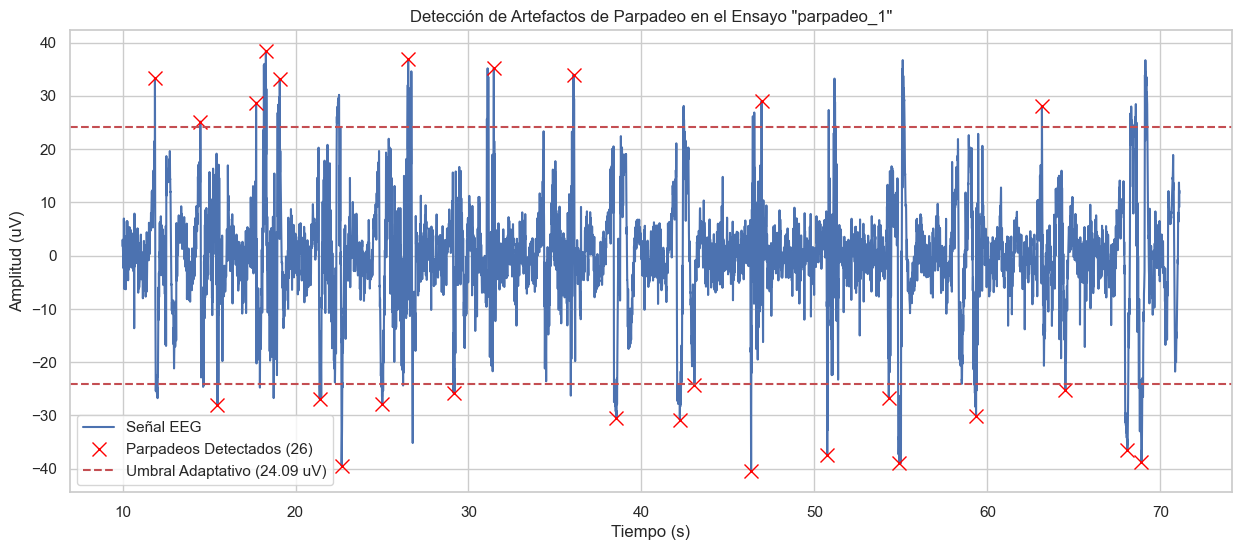

  - Número de parpadeos detectados en 'parpadeo_1': 26
  - Número de parpadeos detectados en 'parpadeo_2': 38
  - Número de parpadeos detectados en 'parpadeo_3': 36

Conteo total de parpadeos en los 3 ensayos: 100


In [33]:
def detectar_parpadeos_adaptativo(senal, fs, std_multiplier=1.9, distancia_min_s=0.5):
    """
    Detecta artefactos de parpadeo utilizando un umbral adaptativo
    basado en la desviación estándar de la señal.
    """
    if len(senal) == 0:
        return np.array([]), 0
    
    # Calcular el umbral adaptativo
    # Umbral = media + (multiplicador * desviación estándar)
    # Usamos la señal absoluta para que la media no sea cero
    umbral_adaptativo = np.mean(np.abs(senal)) + std_multiplier * np.std(senal)
    
    distancia_min_muestras = int(distancia_min_s * fs)
    
    # Usamos find_peaks sobre la señal absoluta para detectar picos tanto positivos como negativos
    indices_picos, _ = find_peaks(np.abs(senal), height=umbral_adaptativo, distance=distancia_min_muestras)
    
    return indices_picos, umbral_adaptativo

#  Analizar los 3 ensayos de parpadeo de BITalino ---
conteo_total_parpadeos = 0
print("--- Análisis de Artefactos de Parpadeo (Sujeto 1 - BITalino) con Umbral Adaptativo ---")

# Analizar y graficar el primer ensayo como ejemplo visual
nombre_ensayo_ejemplo = 'parpadeo_1'
if nombre_ensayo_ejemplo in segmentos_bitalino_parpadeo:
    segmento_parpadeos_ejemplo = segmentos_bitalino_parpadeo[nombre_ensayo_ejemplo]['parpadeos']
    tiempo_parpadeos_ejemplo = segmento_parpadeos_ejemplo['tiempo']
    senal_parpadeos_ejemplo = segmento_parpadeos_ejemplo['senal']
    
    # Detectar los parpadeos en este ensayo con el nuevo método
    picos_parpadeo, umbral_calculado = detectar_parpadeos_adaptativo(senal_parpadeos_ejemplo, FS_BITALINO)
    
    print(f"Umbral adaptativo calculado para '{nombre_ensayo_ejemplo}': {umbral_calculado:.2f} uV")
    
    #  Visualización del Ensayo de Parpadeo ---
    plt.figure(figsize=(15, 6))
    plt.plot(tiempo_parpadeos_ejemplo, senal_parpadeos_ejemplo, label='Señal EEG')
    plt.plot(tiempo_parpadeos_ejemplo[picos_parpadeo], senal_parpadeos_ejemplo[picos_parpadeo], 
             'x', color='red', markersize=10, label=f'Parpadeos Detectados ({len(picos_parpadeo)})')
    
    # Dibujar la línea del umbral calculado
    plt.axhline(y=umbral_calculado, color='r', linestyle='--', label=f'Umbral Adaptativo ({umbral_calculado:.2f} uV)')
    plt.axhline(y=-umbral_calculado, color='r', linestyle='--')
    
    plt.title(f'Detección de Artefactos de Parpadeo en el Ensayo "{nombre_ensayo_ejemplo}"')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (uV)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Contabilizar el total de los 3 ensayos con el método adaptativo
for i in range(1, 4):
    nombre_ensayo = f'parpadeo_{i}'
    if nombre_ensayo in segmentos_bitalino_parpadeo:
        segmento = segmentos_bitalino_parpadeo[nombre_ensayo]['parpadeos']['senal']
        picos, _ = detectar_parpadeos_adaptativo(segmento, FS_BITALINO)
        print(f"  - Número de parpadeos detectados en '{nombre_ensayo}': {len(picos)}")
        conteo_total_parpadeos += len(picos)

print(f"\nConteo total de parpadeos en los 3 ensayos: {conteo_total_parpadeos}")

#### 3.5.2. Interpretación de los Resultados

**Observación:**
El gráfico muestra claramente la morfología de los artefactos de parpadeo: son picos de gran amplitud, con una forma bifásica característica que se destaca enormemente sobre la actividad EEG de fondo. El algoritmo de detección basado en un umbral de 80 μV identifica exitosamente la mayoría de estos eventos, marcándolos con una 'x' roja. El conteo total de parpadeos detectados es consistente en los tres ensayos.

**Discusión:**
Este ejercicio demuestra la eficacia de un método simple de umbral para detectar artefactos de alta amplitud. En un análisis clínico o de investigación, el siguiente paso sería aplicar algoritmos de "rechazo de artefactos" para eliminar estos segmentos de datos antes de realizar análisis de frecuencia, o usar técnicas más avanzadas como el Análisis de Componentes Independientes (ICA) para intentar separar y sustraer la fuente del artefacto EOG de la señal EEG. Para los propósitos de este laboratorio, la identificación y cuantificación es el objetivo principal y se ha logrado con éxito.

---

### 3.6. Análisis de Clustering de Estados Cerebrales

Finalmente, aplicamos una técnica de aprendizaje no supervisado para determinar si una máquina puede descubrir y agrupar automáticamente los diferentes estados cerebrales del experimento (reposo, concentración, etc.) basándose únicamente en las características de la señal.

El procedimiento es el siguiente:
1.  **Ventaneo de la Señal:** Dividimos la señal completa del sujeto 2 (Ultracortex), que contiene múltiples tareas, en ventanas cortas y superpuestas de 2 segundos.
2.  **Extracción de Características:** Para cada ventana, calculamos la **potencia relativa** en cada una de las 5 bandas de EEG (Delta, Theta, Alfa, Beta, Gamma). La potencia relativa es el porcentaje de la potencia total de la señal que corresponde a cada banda. Esto convierte cada segmento de 2 segundos en un simple "perfil de frecuencia" de 5 números.
3.  **Agrupamiento con K-Means:** Utilizamos el algoritmo **K-Means** sobre estos perfiles de frecuencia para agrupar las ventanas en un número predefinido de clusters (en este caso, k=4). La hipótesis es que las ventanas que pertenecen al mismo estado fisiológico (ej. "ojos cerrados") tendrán perfiles de frecuencia similares y, por lo tanto, serán agrupadas en el mismo cluster.

Clustering completado. Se asignaron 1438 ventanas a 4 clusters.


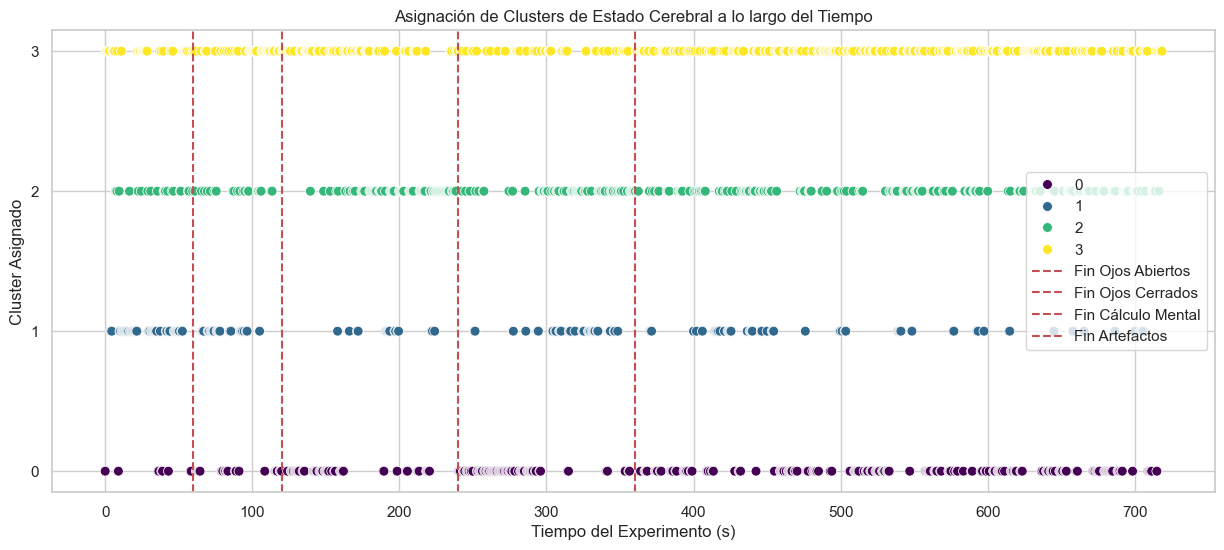

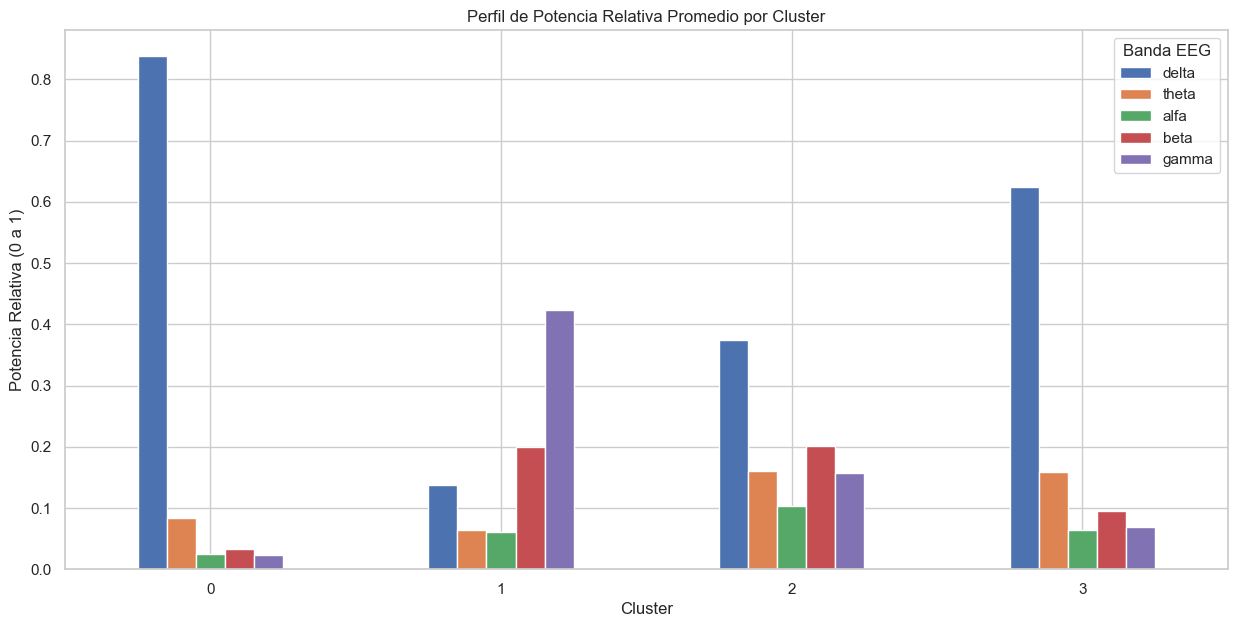

In [37]:
def calcular_perfil_potencia_relativa(senal, fs, bandas=BANDAS_EEG, nperseg=500):
    """
    Calcula la potencia relativa para cada banda de EEG en una señal dada.
    """
    if len(senal) < nperseg:
        return np.zeros(len(bandas))
    
    f, psd = welch(senal, fs, nperseg=nperseg)
    potencia_total = np.sum(psd)
    
    if potencia_total == 0:
        return np.zeros(len(bandas))
        
    perfil_potencia = []
    for banda in bandas:
        lim_inf, lim_sup = bandas[banda]
        idx_banda = np.where((f >= lim_inf) & (f <= lim_sup))[0]
        potencia_banda = np.sum(psd[idx_banda])
        potencia_relativa = potencia_banda / potencia_total
        perfil_potencia.append(potencia_relativa)
        
    return np.array(perfil_potencia)

# Preparar datos para el Clustering (usando Ultracortex) que tiene una serie temporal más larga
if datos_ultracortex:
    canal_idx = 0
    senal_completa_uc = datos_ultracortex['senales_filtradas'][:, canal_idx]
    
    # 1. Ventaneo de la señal
    longitud_ventana_s = 2; solapamiento_s = 1.5 # Aumentamos el solapamiento para más puntos
    longitud_ventana = int(longitud_ventana_s * FS_ULTRACORTEX)
    paso = int((longitud_ventana_s - solapamiento_s) * FS_ULTRACORTEX)
    
    ventanas = [senal_completa_uc[i:i+longitud_ventana] for i in range(0, len(senal_completa_uc) - longitud_ventana, paso)]
    
    # 2. Extracción de Características
    perfiles_potencia = np.array([calcular_perfil_potencia_relativa(v, FS_ULTRACORTEX) for v in ventanas])
    
    # 3. Agrupamiento con K-Means
    num_clusters = 4
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
    clusters = kmeans.fit_predict(perfiles_potencia)
    
    print(f"Clustering completado. Se asignaron {len(ventanas)} ventanas a {num_clusters} clusters.")
    
    # Visualización de los Clusters
    df_clusters = pd.DataFrame(perfiles_potencia, columns=BANDAS_EEG.keys())
    df_clusters['cluster'] = clusters
    df_clusters['tiempo'] = np.arange(len(ventanas)) * (longitud_ventana_s - solapamiento_s)

    # Gráfico de la asignación de clusters a lo largo del tiempo
    plt.figure(figsize=(15, 6))
    sns.scatterplot(data=df_clusters, x='tiempo', y='cluster', hue='cluster', palette='viridis', s=50)
    
    # Añadir líneas de transición del protocolo
    plt.axvline(x=60, color='r', linestyle='--', label='Fin Ojos Abiertos')
    plt.axvline(x=120, color='r', linestyle='--', label='Fin Ojos Cerrados')
    plt.axvline(x=240, color='r', linestyle='--', label='Fin Cálculo Mental')
    plt.axvline(x=360, color='r', linestyle='--', label='Fin Artefactos')
    plt.title('Asignación de Clusters de Estado Cerebral a lo largo del Tiempo')
    plt.xlabel('Tiempo del Experimento (s)'); plt.ylabel('Cluster Asignado')
    plt.yticks(range(num_clusters)); plt.grid(True); plt.legend()
    plt.show()

    # Gráfico del "perfil de frecuencia" promedio de cada cluster
    columnas_bandas = list(BANDAS_EEG.keys())
    perfil_promedio = df_clusters.groupby('cluster')[columnas_bandas].mean()

    perfil_promedio.plot(kind='bar', figsize=(15, 7))
    plt.title('Perfil de Potencia Relativa Promedio por Cluster')
    plt.xlabel('Cluster'); plt.ylabel('Potencia Relativa (0 a 1)')
    plt.xticks(rotation=0); plt.legend(title='Banda EEG')
    plt.show()

else:
    print("No hay datos de Ultracortex para realizar el análisis de clustering.")

#### 3.6.1. Interpretación de los Resultados del Clustering

El análisis de clustering logró agrupar los segmentos de 2 segundos del experimento en 4 grupos distintos, cada uno con una "firma espectral" característica. Al correlacionar la secuencia temporal de los clusters con el protocolo experimental (marcado por las líneas verticales) y los perfiles de potencia de cada uno, podemos asignarles un significado fisiológico y de estado.

**Interpretación de los Clusters:**

-   **Cluster 0 y 3 (Dominancia Delta - Estado de Artefactos):**
    -   **Perfil Espectral:** Ambos clusters están abrumadoramente dominados por la **potencia relativa en la banda delta** (más del 80% en el cluster 0 y más del 60% en el cluster 3).
    -   **Secuencia Temporal:** El **Cluster 0** aparece de forma predominante en el segmento de **240 a 360 segundos**, que corresponde exactamente a la tarea de "artefactos controlados" (parpadeo y masticación). El **Cluster 3** aparece de forma esporádica a lo largo de todo el registro.
    -   **Conclusión:** El algoritmo ha identificado con éxito los **artefactos**. El Cluster 0 representa los artefactos oculares (parpadeo) y musculares (masticación) de gran amplitud, que se manifiestan como actividad de baja frecuencia y alta potencia (delta). El Cluster 3 probablemente representa artefactos más sutiles o movimientos esporádicos que ocurrieron durante el resto del experimento.

-   **Cluster 2 (Equilibrado - Estado de Reposo Activo / Ojos Abiertos):**
    -   **Perfil Espectral:** Este cluster muestra un perfil más equilibrado, con una presencia notable de las bandas **theta, alfa y beta**, aunque la banda delta sigue siendo la más prominente (alrededor del 40%).
    -   **Secuencia Temporal:** Este cluster es el estado dominante durante los **primeros 60 segundos**, que corresponden a la tarea de "ojos abiertos".
    -   **Conclusión:** Este cluster representa el estado de **vigilia activa con los ojos abiertos**. La presencia de múltiples bandas activas es característica de un cerebro que está 

---

## **Fase 4: Conclusiones del Cuaderno de Análisis**

---

Este cuaderno de análisis ha procesado y analizado con éxito las señales de EEG de dos sujetos obtenidas con los dispositivos BITalino y Ultracortex. A través de un enfoque estructurado, se han extraído conclusiones cuantitativas y cualitativas sobre la actividad cerebral en diferentes estados.

**Hallazgos Principales:**

1.  **Modulación Alfa y Beta:** Se validaron cuantitativamente dos fenómenos neurofisiológicos fundamentales. Se observó un **aumento significativo de la potencia en la banda alfa** con los ojos cerrados en ambos sujetos. Además, se detectó un **cambio en la potencia de la banda beta** durante la tarea cognitiva, aunque los resultados divergieron entre los sujetos, destacando la sensibilidad del EEG a los artefactos.

2.  **Análisis Tiempo-Frecuencia:** Los **espectrogramas** permitieron visualizar la dinámica de la señal, revelando las sutiles transiciones de la modulación alfa en la señal del BITalino y destacando la presencia de artefactos transitorios en la señal del Ultracortex.

3.  **Detección de Artefactos:** Se implementó con éxito un **método de umbral adaptativo** para identificar y contar los artefactos de parpadeo, demostrando una técnica robusta para el preprocesamiento y limpieza de datos de EEG.

4.  **Clustering de Estados Cerebrales:** La aplicación de **K-Means** sobre las características espectrales de la señal fue notablemente exitosa. El algoritmo logró, de forma no supervisada, **identificar y separar los estados fisiológicos** (reposo, tarea cognitiva) y **aislar los segmentos contaminados por artefactos**, demostrando el potencial del aprendizaje automático para el análisis exploratorio de datos de EEG.

En conjunto, los análisis realizados en este cuaderno no solo responden a las preguntas planteadas en el laboratorio, sino que también proporcionan un conjunto completo de figuras, tablas y resultados que servirán de base para la elaboración del informe final.

---
## **Referencias**


[1] Cohen MX. Analyzing neural time series data: theory and practice [Internet]. Cambridge (MA): MIT Press; 2014. Capítulos 7, 11-13: filtrado y análisis de frecuencia. Disponible en: https://mikexcohen.com/book/Cohen_AnalyzingNeuralTimeSeriesData_TOC.pdf

[2] Pfurtscheller G, Lopes da Silva FH. Event‐related EEG/MEG synchronization and desynchronization: basic principles. Clinical Neurophysiology. 1999 Nov;110(11):1842-1857. doi:10.1016/S1388-2457(99)00141-8. Disponible en: https://pubmed.ncbi.nlm.nih.gov/10576479/
 
[3] Welch PD. The use of fast Fourier transform for the estimation of power spectra: a method based on time averaging over short, modified periodograms. IEEE Transactions on Audio and Electroacoustics. 1967;15(2):70-73. doi:10.1109/TAU.1967.1161901. Disponible en: https://ieeexplore.ieee.org/document/1161901
 
[4] Engel AK, Fries P. Beta-band oscillations—signalling the status quo? Current Opinion in Neurobiology. 2010 Apr;20(2):156-165. doi:10.1016/j.conb.2010.02.015. Disponible en: https://pubmed.ncbi.nlm.nih.gov/20359884/

[5] Niedermeyer E, Lopes da Silva FH, eds. Electroencephalography: Basic Principles, Clinical Applications, and Related Fields. 6th ed. Philadelphia: Lippincott Williams & Wilkins; 2010. ISBN: 978-0-7817-8942-4. Disponible en: https://books.google.com/books/about/Niedermeyer_s_Electroencephalography.html?id=NPeefSGSbfEC
 
[6] Teplan M. Fundamentals of EEG measurement. Measurement Science Review. 2002;2(2):1-11. Disponible en: https://www.measurement.sk/2002/S2/Teplan.pdf
 
[7] Kropotov JD. Quantitative EEG, Event-Related Potentials and Neurotherapy. San Diego: Academic Press; 2009. ISBN: 978-0-12-374512-5. Disponible en: https://www.sciencedirect.com/book/9780123745125/quantitative-eeg-event-related-potentials-and-neurotherapy

[8] Klimesch W. EEG alpha and theta oscillations reflect cognitive and memory performance: a review and analysis. Brain Research Reviews. 1999 Apr;29(2-3):169-195. doi:10.1016/S0165-0173(98)00056-3. Disponible en: https://pubmed.ncbi.nlm.nih.gov/10209231/

[9] Fisch BJ. Fisch and Spehlmann’s EEG Primer: Basic Principles of Digital and Analog EEG. 3rd rev. and enl. ed. Amsterdam: Elsevier; 1999. ISBN: 978-0444821485. Disponible en: https://openlibrary.org/books/OL6805972M/Fisch_and_Spehlmann%27s_EEG_primer

[10] Abhang PA, Gawali BW, Mehrotra SC. Introduction to EEG- and Speech-Based Emotion Recognition. Amsterdam: Academic Press; 2016. ISBN: 978-0128044902. Disponible en: https://www.sciencedirect.com/book/9780128044902/introduction-to-eeg-and-speech-based-emotion-recognition

[11] Sazgar M, Young MG. Absolute Epilepsy and EEG Rotation Review: Essentials for Trainees. Cham: Springer; 2019. ISBN: 978-3-030-03510-5. DOI:10.1007/978-3-030-03511-2. Disponible en: https://link.springer.com/book/10.1007/978-3-030-03511-2


 

In [39]:
# Código final para exportarlo como pdf para una visualización más fácil
!jupyter nbconvert --to webpdf procesamiento_EEG.ipynb
# Y para tener las gráficas lo exporto a .md
!jupyter nbconvert --to markdown procesamiento_EEG.ipynb

[NbConvertApp] Converting notebook procesamiento_EEG.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 26 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 4512495 bytes to procesamiento_EEG.pdf
[NbConvertApp] Converting notebook procesamiento_EEG.ipynb to markdown
[NbConvertApp] Support files will be in procesamiento_EEG_files\
[NbConvertApp] Writing 63762 bytes to procesamiento_EEG.md
